# Macroeconomics II Group project 2026
## Country: Switzerland

# Data Cleaning
Importing Relevant libraries for data analysis

In [ ]:
# Import relevant libraries

# Libraries for calling matrices, performing operations, calculating statsitics.
import numpy as np
import pandas as pd
from scipy import stats
# Library for calling file out of relevant directory
import os
# Libraries for data visualisations
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('talk', style = 'white')

Importing data into collab from personal google drive (Penn World Table data loaded)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to the Excel file (in drive)
data_path = "/content/drive/MyDrive/Macro_Project_jan26/pwt.xlsx"

# Load the "Data" sheet
data = pd.read_excel(data_path, sheet_name="Data")

In [ ]:

# Check if imported data is ok
data

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,ABW,Aruba,Aruban Guilder,1950,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,Aruban Guilder,1951,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,Aruban Guilder,1952,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,Aruban Guilder,1953,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,Aruban Guilder,1954,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13685,ZWE,Zimbabwe,US Dollar,2019,46541.140625,45106.468750,15.271368,5.272343,1903.71,2.713408,...,0.189066,-0.242234,0.038880,0.501244,0.534841,0.345942,0.505318,0.441230,0.339268,1.346716
13686,ZWE,Zimbabwe,US Dollar,2020,45985.085938,45983.898438,15.526888,5.206007,1889.45,2.746586,...,0.110438,-0.165574,0.029654,0.500685,0.519637,0.290690,0.772591,0.680202,0.324105,1.353769
13687,ZWE,Zimbabwe,US Dollar,2021,45625.347656,44440.199219,15.797210,5.298346,2011.57,2.770661,...,0.172298,-0.279770,0.024442,0.616105,0.549380,0.301370,0.558099,0.497615,0.347739,1.064607
13688,ZWE,Zimbabwe,US Dollar,2022,50148.527344,48054.238281,16.069056,5.344455,2172.04,2.795292,...,0.220504,-0.391468,0.021712,0.660731,0.478931,0.280778,0.487665,0.432867,0.301817,1.006796


Keeping only the relevant subset

In [ ]:
# Select Switzerland and arrange years in correct order, restrict to required years

data = data[data["country"] == "Switzerland"].copy()
data = data.sort_values("year").reset_index(drop=True)

ymin = 1950
ymax = 2023

data = data[(data["year"] >= ymin) & (data["year"] <= ymax)].copy()

In [ ]:
#Choose variables required and define them as columns
cols = [
    "country", "year",
    "rgdpna",   # rgdpna - Real GDP at constant 2021 national prices (in mil. 2021US$)
    "pop",      # pop	- Population (in millions)
    "emp",      # emp -	Number of persons engaged (in millions)
    "rnna",     # rnna - Capital stock at constant 2021 national prices (in mil. 2021US$)
    "hc",        # hc	- Human capital index, based on years of schooling and returns to education; see Human capital in PWT9.
    "avh",       # avh -	Average annual hours worked by persons engaged
    "rconna",    # cons - Real consumption at constant 2021 national prices (in mil. 2021US$)
]

data = data.loc[:, cols]

In [ ]:
# Labelling Variables for ease
Y = data["rgdpna"] # Real GDP at constant 2021 national prices (in mil. 2021US$)
N = data["pop"]    # pop	- Population (in millions)
L = data["emp"]    # emp -	Number of persons engaged (in millions)
K = data["rnna"]   # rnna - Capital stock at constant 2021 national prices (in mil. 2021US$)
HC = data["hc"]    # hc	- Human capital index, based on years of schooling and returns to education; see Human capital in PWT9.
AVH = data["avh"]  # avh -	Average annual hours worked by persons engaged

In [ ]:
# Scaling the variables up (multiple by 10^6) for ease of analysis
Y = data["rgdpna"] * 1e6      # Real GDP in 2021 US$
N = data["pop"] * 1e6         # Population
L = data["emp"] * 1e6         # Number of persons engaged
K = data["rnna"] * 1e6        # Capital stock in 2021 US$

In [ ]:
# Checking data again
data

,country,year,rgdpna,pop,emp,rnna,hc,avh,rconna
0,Switzerland,1950,133874.484375,4.629527,2.276792,4.953965e+05,2.935118,2042.67,76479.976562
1,Switzerland,1951,144721.203125,4.683772,2.359442,5.046018e+05,2.941377,2035.01,77758.218750
2,Switzerland,1952,145916.187500,4.748865,2.403922,5.099612e+05,2.947650,2027.39,79108.851562
3,Switzerland,1953,151082.187500,4.811000,2.421083,5.156271e+05,2.953936,2019.79,80762.546875
4,Switzerland,1954,159538.968750,4.861299,2.448107,5.268248e+05,2.960236,2012.22,83600.585938
...,...,...,...,...,...,...,...,...,...
69,Switzerland,2019,746353.500000,8.577524,5.049824,3.478718e+06,3.702678,1549.12,366888.562500
70,Switzerland,2020,730368.562500,8.640582,5.023572,3.542198e+06,3.710290,1498.80,359260.187500
71,Switzerland,2021,770974.375000,8.707023,5.057027,3.608992e+06,3.721797,1532.48,367827.781250
72,Switzerland,2022,794443.312500,8.792182,5.139609,3.673966e+06,3.733380,1536.15,379676.062500


# TASK A: Trend calculation

## Regression 1: Linear, additive and exponential specifications

We want to run the following regressions and visualise them:

$Y_t = \alpha + \beta \times t + \epsilon_t $

$y_t = \alpha + \beta \times t + \epsilon_t $

$ln(Y_t) = \alpha + \beta \times t + \epsilon_t $

$ln(y_t) = \alpha + \beta \times t + \epsilon_t $

where $Y_t$ is Real GDP at year t, $y_t$ is Real GDP per capita at year t, and t is the year.

In [ ]:
# Defining a function to perform Linear Regression, store coefficients and confidence intervals
# Calculating trend time paths for real GDP, real GDP per capita and their natural logs

def get_regression_coefs(Y, *args): # defines a function in order to obtain regression coefficients.
                                    # *args is a command that flexibly allows for different number of inputs into a function.
    T = len(args[0])          # defines the number of observations(rows)
                              # i.e., time periods (T) in the sample, as the number of elements in the first element of *args
    N = len(args)             # defines the number of regressors (columns) as the number of elements in *args

    # Constructing the X matrix
    X = np.empty((T, N)) # we use numpy to create a matrix with T rows and N columns. (T - time periods, N - number of regressors)
    for ix in range(N): # we use for loop to loop over columns of indices 0 to N-1
        X[:, ix] = args[ix] # For each column ix, this command takes values from arg[ix] and adds it to X. Through this, we create a T x N matrix.

    # OLS estimates
    XX = X.T @ X # defines the XX matrix by multiplying X transpose (N x T) with X (T x N)
    XY = X.T @ Y # defines the XY matrix by multipying X transpose (N x T) with Y (T x 1)
    coefs = np.linalg.inv(XX) @ XY # defines the column vector of regression coefficients by multiplying the inverse of XX matrix with XY

    # Residuals
    Y_hat = X @ coefs # defining the vector of fitted values from the regression
    residuals = Y - Y_hat # defining the residuals from the regression

    # Estimated variance of error term
    sigma2 = (residuals @ residuals) / (T - N)

    # Estimated variance-covariance matrix of coefficients
    var_beta = sigma2 * np.linalg.inv(XX) # defines the variance-covariance matrix by multiplying the estimated variance of the error term with the inverse of XX matrix

    # Standard errors
    std_err = np.sqrt(np.diag(var_beta)) # defines the standard errors by obtaining the square root of the variance-covariance matrix

    # 95% confidence intervals
    ci_lower = coefs - 1.96 * std_err # defines the 95% confidence interval (t_critical = 1.96)
    ci_upper = coefs + 1.96 * std_err

    return coefs, std_err, ci_lower, ci_upper

# Defining the time variable and intercept
x2 = np.arange(1, len(data) + 1)  # creates a year sequence of t from 1 to T
x1 = np.ones(len(x2))     # creates the intercept term as a column of ones

# Calculating logs of real GDP and real GDP per capita
Y = data["rgdpna"].values # takes values (real GDP) from the 'rgdpna' column. Converts it into a NumPy array and stores it in Y
y = (data["rgdpna"] / data["pop"]).values # obtains values (real GDP per capita) by dividing data from the 'rgdpna' and 'pop' column. Converts it into a NumPy array and stores it in y
ln_Y = np.log(Y) # defines the natural log of real GDP
ln_y = np.log(y) # defines the natural log of real GDP per capita

# Run linear and log-linear regressions using the get_regression_coefs function to obtain the coefficients, standard errors and confidence intervals
coefs_Y, se_Y, ci_lower_Y, ci_upper_Y = get_regression_coefs(ln_Y, x1, x2) # for log of real GDP
coefs_y, se_y, ci_lower_y, ci_upper_y = get_regression_coefs(ln_y, x1, x2) # for log of real GDP per capita
coefs_Y1, se_Y1, ci_lower_Y1, ci_upper_Y1 = get_regression_coefs(Y, x1, x2) # for real GDP
coefs_y1, se_y1, ci_lower_y1, ci_upper_y1 = get_regression_coefs(y, x1, x2) # for real GDP per capita

# Printing the results of regressions
print("\nln(Real GDP) = α + β·t + ε")
print(f"α = {coefs_Y[0]:.4f} (SE: {se_Y[0]:.4f}), 95% CI: [{ci_lower_Y[0]:.4f}, {ci_upper_Y[0]:.4f}]") # obtaining  with 4 decimal places
print(f"β = {coefs_Y[1]:.4f} (SE: {se_Y[1]:.4f}), 95% CI: [{ci_lower_Y[1]:.4f}, {ci_upper_Y[1]:.4f}]")

print("\nln(GDP per capita) = α + β·t + ε")
print(f"α = {coefs_y[0]:.4f} (SE: {se_y[0]:.4f}), 95% CI: [{ci_lower_y[0]:.4f}, {ci_upper_y[0]:.4f}]")
print(f"β = {coefs_y[1]:.4f} (SE: {se_y[1]:.4f}), 95% CI: [{ci_lower_y[1]:.4f}, {ci_upper_y[1]:.4f}]")

print("\nReal GDP = α + β·t + ε")
print(f"α = {coefs_Y1[0]:.4f} (SE: {se_Y1[0]:.4f}), 95% CI: [{ci_lower_Y1[0]:.4f}, {ci_upper_Y1[0]:.4f}]")
print(f"β = {coefs_Y1[1]:.4f} (SE: {se_Y1[1]:.4f}), 95% CI: [{ci_lower_Y1[1]:.4f}, {ci_upper_Y1[1]:.4f}]")

print("\nGDP per capita = α + β·t + ε")
print(f"α = {coefs_y1[0]:.4f} (SE: {se_y1[0]:.4f}), 95% CI: [{ci_lower_y1[0]:.4f}, {ci_upper_y1[0]:.4f}]")
print(f"β = {coefs_y1[1]:.4f} (SE: {se_y1[1]:.4f}), 95% CI: [{ci_lower_y1[1]:.4f}, {ci_upper_y1[1]:.4f}]")


ln(Real GDP) = α + β·t + ε
α = 12.0786 (SE: 0.0254), 95% CI: [12.0288, 12.1284]
β = 0.0216 (SE: 0.0006), 95% CI: [0.0204, 0.0227]

ln(GDP per capita) = α + β·t + ε
α = 10.4833 (SE: 0.0196), 95% CI: [10.4449, 10.5217]
β = 0.0138 (SE: 0.0005), 95% CI: [0.0129, 0.0147]

Real GDP = α + β·t + ε
α = 119936.5837 (SE: 5620.2410), 95% CI: [108920.9113, 130952.2560]
β = 8456.2081 (SE: 130.2287), 95% CI: [8200.9598, 8711.4564]

GDP per capita = α + β·t + ε
α = 32752.0174 (SE: 600.0523), 95% CI: [31575.9149, 33928.1199]
β = 792.5982 (SE: 13.9040), 95% CI: [765.3463, 819.8502]


In [ ]:
# Obtaining Fitted values by substituting the coefficients obtained through regression
fitted_Y = coefs_Y[0] + coefs_Y[1] * x2  # fitted values of real GDP
fitted_y = coefs_y[0] + coefs_y[1] * x2  # fitted values of real GDP per capita
fitted_Y1 = coefs_Y1[0] + coefs_Y1[1] * x2 # fitted values of log real GDP
fitted_y1 = coefs_y1[0] + coefs_y1[1] * x2 # fitted values of log real GDP per capita

# 95% Confidence intervals for fitted line

X = np.column_stack([x1, x2]) # defining the X matrix by including the x1 and x2 vectors (intercept and regressors)
T = len(x1) # number of time periods T - length of the number of elements in the intercept vector (sample size)
XX_inv = np.linalg.inv(X.T @ X) # defining XX_inv matrix

# Variance of the fitted values for the regressions
var_fitted_Y = np.sum((X @ XX_inv) * X, axis=1) * (np.sum((ln_Y - fitted_Y)**2) / (T - 2)) # for real GDP
var_fitted_y = np.sum((X @ XX_inv) * X, axis=1) * (np.sum((ln_y - fitted_y)**2) / (T - 2)) # for real GDP per capita
var_fitted_Y1 = np.sum((X @ XX_inv) * X, axis=1) * (np.sum((Y - fitted_Y1)**2) / (T - 2)) # for log real GDP
var_fitted_y1 = np.sum((X @ XX_inv) * X, axis=1) * (np.sum((y - fitted_y1)**2) / (T - 2)) # for log real GDP per capita

ci_band_Y_lower = fitted_Y - 1.96 * np.sqrt(var_fitted_Y) # lower and upper bounds of the confidence intervals of coefficients obtained from the four regressions for Y, y, Y1, y1
ci_band_Y_upper = fitted_Y + 1.96 * np.sqrt(var_fitted_Y)
ci_band_y_lower = fitted_y - 1.96 * np.sqrt(var_fitted_y)
ci_band_y_upper = fitted_y + 1.96 * np.sqrt(var_fitted_y)
ci_band_Y1_lower = fitted_Y1 - 1.96 * np.sqrt(var_fitted_Y1)
ci_band_Y1_upper = fitted_Y1 + 1.96 * np.sqrt(var_fitted_Y1)
ci_band_y1_lower = fitted_y1 - 1.96 * np.sqrt(var_fitted_y1)
ci_band_y1_upper = fitted_y1 + 1.96 * np.sqrt(var_fitted_y1)

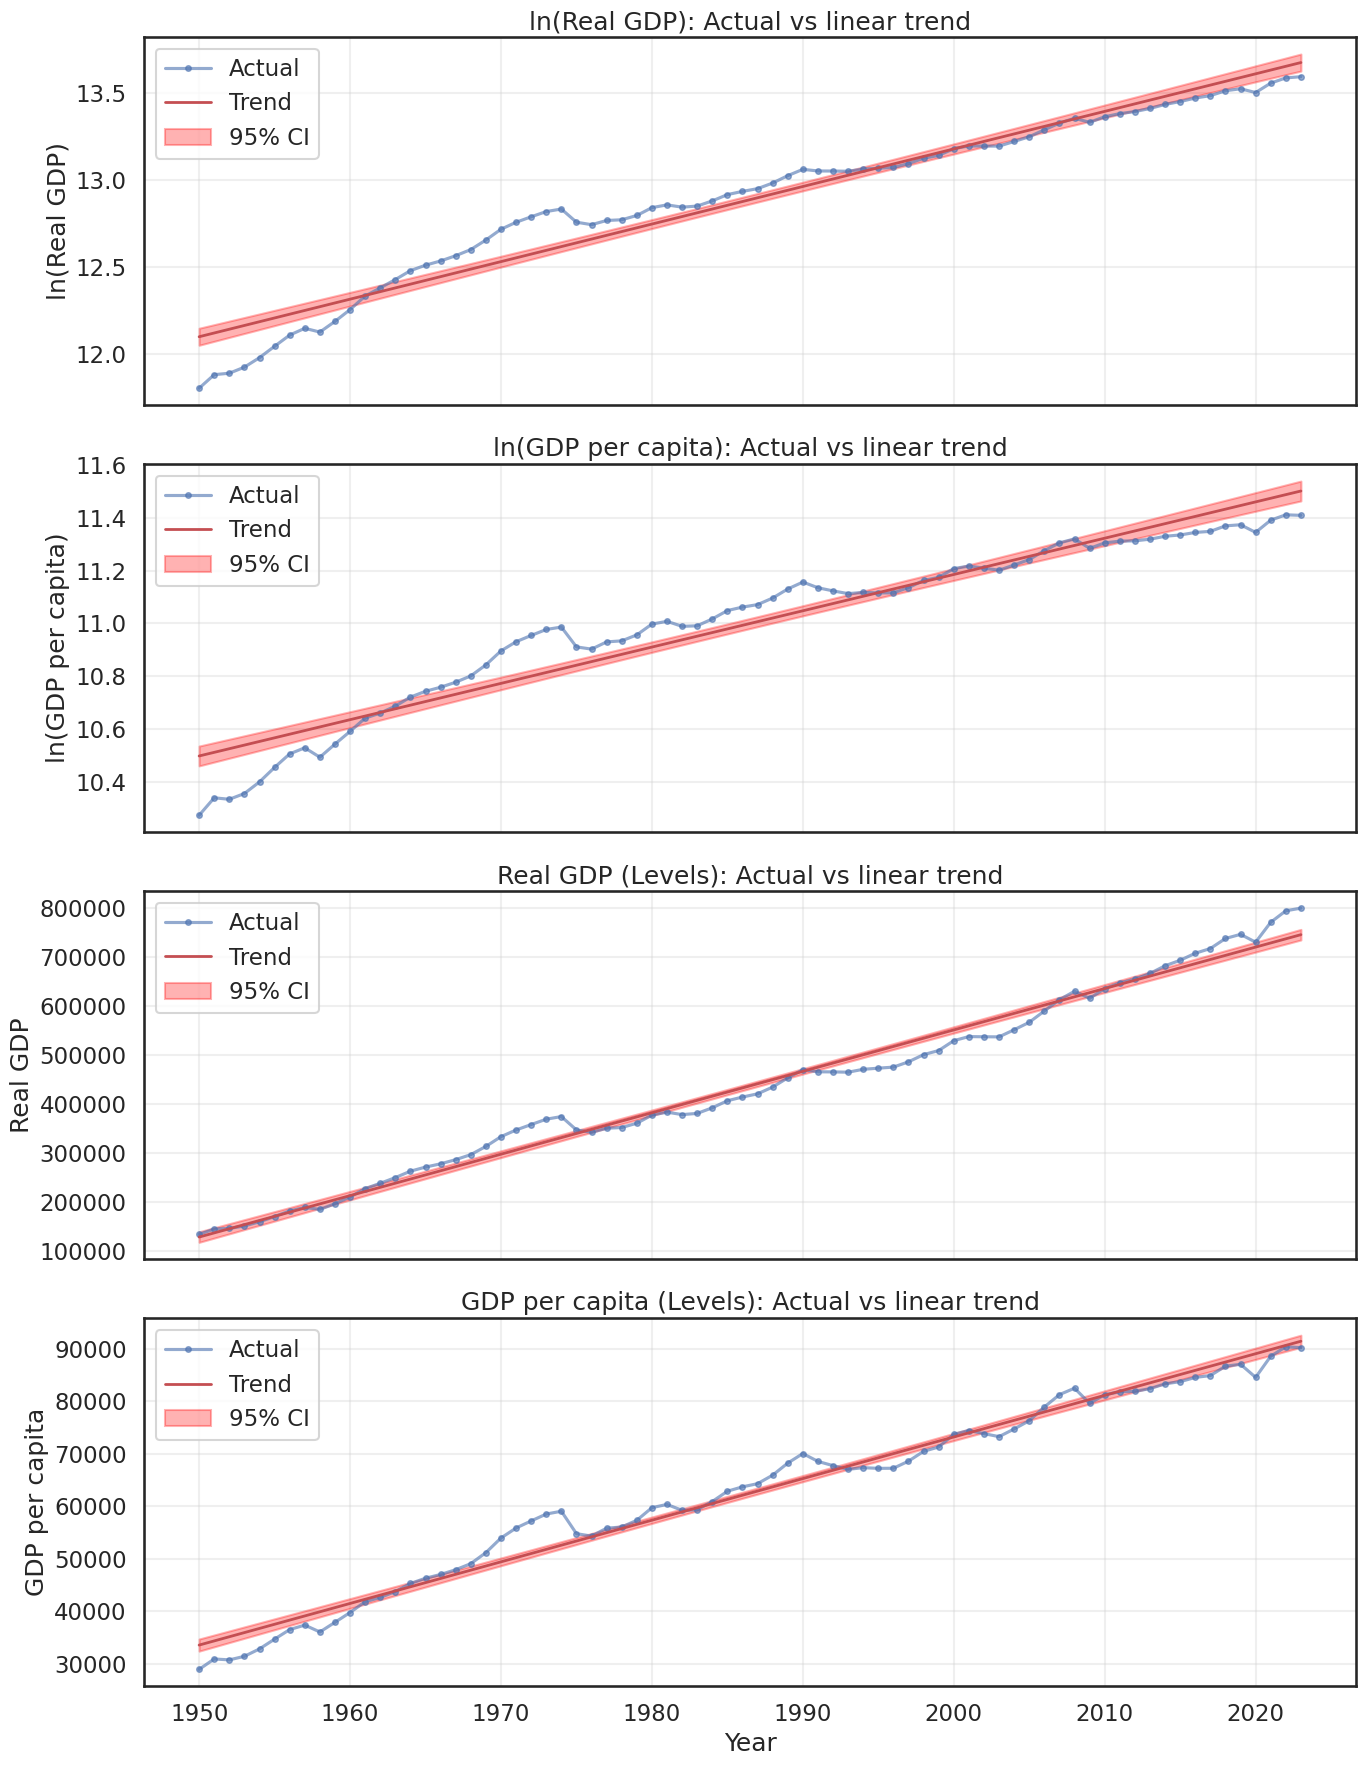

In [ ]:
import matplotlib.pyplot as plt

# Visualizing the fitted trends
# Including the title, x and y labels, legend, confidence intervals
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

# 1. ln(Real GDP)
axes[0].plot(data["year"], ln_Y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[0].plot(data["year"], fitted_Y, 'r-', linewidth=2, label='Trend') # plotting the fitted trend line in red
axes[0].fill_between(data["year"], ci_band_Y_lower, ci_band_Y_upper,
                     alpha=0.3, color='red', label='95% CI') # shading the 95% confidence interval around the fitted trend
axes[0].set_title('ln(Real GDP): Actual vs linear trend')  # setting the title of the first subplot
axes[0].set_ylabel('ln(Real GDP)') # labelling the y-axis
axes[0].legend() # to display the legend
axes[0].grid(alpha=0.3) # adding a light grid for readability

# 2. ln(GDP per capita)
axes[1].plot(data["year"], ln_y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[1].plot(data["year"], fitted_y, 'r-', linewidth=2, label='Trend')
axes[1].fill_between(data["year"], ci_band_y_lower, ci_band_y_upper,
                     alpha=0.3, color='red', label='95% CI')
axes[1].set_title('ln(GDP per capita): Actual vs linear trend')
axes[1].set_ylabel('ln(GDP per capita)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Real GDP (levels)
axes[2].plot(data["year"], Y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[2].plot(data["year"], fitted_Y1, 'r-', linewidth=2, label='Trend')
axes[2].fill_between(data["year"], ci_band_Y1_lower, ci_band_Y1_upper,
                     alpha=0.3, color='red', label='95% CI')
axes[2].set_title('Real GDP (Levels): Actual vs linear trend')
axes[2].set_ylabel('Real GDP')
axes[2].legend()
axes[2].grid(alpha=0.3)

# 4. GDP per capita (levels)
axes[3].plot(data["year"], y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[3].plot(data["year"], fitted_y1, 'r-', linewidth=2, label='Trend')
axes[3].fill_between(data["year"], ci_band_y1_lower, ci_band_y1_upper,
                     alpha=0.3, color='red', label='95% CI')
axes[3].set_title('GDP per capita (Levels): Actual vs linear trend')
axes[3].set_xlabel('Year')
axes[3].set_ylabel('GDP per capita')
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

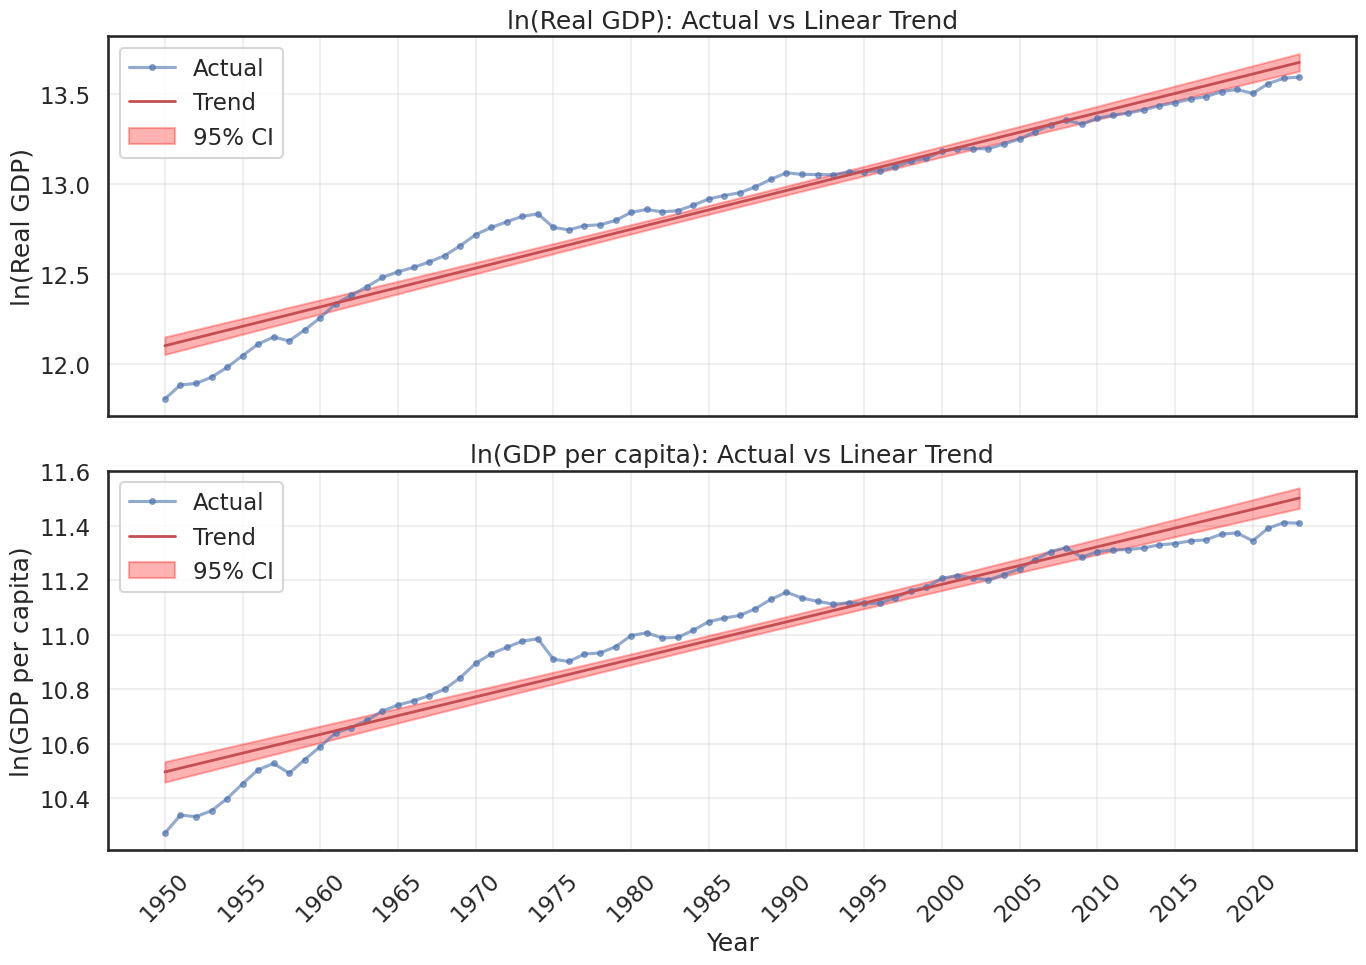

In [ ]:
import matplotlib.pyplot as plt

# Create figure with ONLY 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 1. ln(Real GDP)
axes[0].plot(data["year"], ln_Y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[0].plot(data["year"], fitted_Y, 'r-', linewidth=2, label='Trend')
axes[0].fill_between(data["year"], ci_band_Y_lower, ci_band_Y_upper,
                     alpha=0.3, color='red', label='95% CI')

axes[0].set_title('ln(Real GDP): Actual vs Linear Trend')
axes[0].set_ylabel('ln(Real GDP)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. ln(GDP per capita)
axes[1].plot(data["year"], ln_y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[1].plot(data["year"], fitted_y, 'r-', linewidth=2, label='Trend')
axes[1].fill_between(data["year"], ci_band_y_lower, ci_band_y_upper,
                     alpha=0.3, color='red', label='95% CI')

axes[1].set_title('ln(GDP per capita): Actual vs Linear Trend')
axes[1].set_ylabel('ln(GDP per capita)')
axes[1].set_xlabel('Year')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ---- Show only every 5th year on x-axis ----
five_year_ticks = data["year"][data["year"] % 5 == 0]

axes[1].set_xticks(five_year_ticks)
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()


## Regression 2: Quadratic, additive and exponential specifications

We want to run the following regressions and visualise them:

$Y_t = \alpha + \beta \times t + \gamma \times t^2 + \epsilon_t $

$y_t = \alpha + \beta \times t + \gamma \times t^2 + \epsilon_t $

$ln(Y_t) = \alpha + \beta \times t + \gamma \times t^2 + \epsilon_t $

$ln(y_t) = \alpha + \beta \times t + \gamma \times t^2 + \epsilon_t $

where $Y_t$ is Real GDP at year t, $y_t$ is Real GDP per capita at year t, and t is the year.

In [ ]:
# We already defined a function to perform Linear Regression, store coefficients and confidence intervals
# Calculating (quadratic) trend time paths for real GDP, real GDP per capita and their natural logs

# Defining the time variables and intercept
x2 = np.arange(1, len(data) + 1)  # creates a year sequence of t from 1 to T
x3 = x2**2 # creates a sequence of t^2
x1 = np.ones(len(x2)) # creates the intercept term as a column of ones

# Calculating the natural logs
Y = data["rgdpna"].values
y = (data["rgdpna"] / data["pop"]).values
ln_Y = np.log(Y)
ln_y = np.log(y)

# Run regressions with quadratic term using the get_regression_coefs function
coefs_ln_Y, se_ln_Y, ci_lower_ln_Y, ci_upper_ln_Y = get_regression_coefs(ln_Y, x1, x2, x3) # for log real GDP
coefs_ln_y, se_ln_y, ci_lower_ln_y, ci_upper_ln_y = get_regression_coefs(ln_y, x1, x2, x3) # for log real GDP per capita
coefs_Y, se_Y, ci_lower_Y, ci_upper_Y = get_regression_coefs(Y, x1, x2, x3) # for real GDP
coefs_y, se_y, ci_lower_y, ci_upper_y = get_regression_coefs(y, x1, x2, x3) # for real GDP per capita

# Printing the results of regressions
print("\nln(Real GDP) = α + β·t + γ·t² + ε")
print(f"α = {coefs_ln_Y[0]:.4f} (SE: {se_ln_Y[0]:.4f}), 95% CI: [{ci_lower_ln_Y[0]:.4f}, {ci_upper_ln_Y[0]:.4f}]") # obtainig values with 4 decimal places
print(f"β = {coefs_ln_Y[1]:.4f} (SE: {se_ln_Y[1]:.4f}), 95% CI: [{ci_lower_ln_Y[1]:.4f}, {ci_upper_ln_Y[1]:.4f}]")
print(f"γ = {coefs_ln_Y[2]:.4f} (SE: {se_ln_Y[2]:.4f}), 95% CI: [{ci_lower_ln_Y[2]:.4f}, {ci_upper_ln_Y[2]:.4f}]")

print("\nln(GDP per capita) = α + β·t + γ·t² + ε")
print(f"α = {coefs_ln_y[0]:.4f} (SE: {se_ln_y[0]:.4f}), 95% CI: [{ci_lower_ln_y[0]:.4f}, {ci_upper_ln_y[0]:.4f}]")
print(f"β = {coefs_ln_y[1]:.4f} (SE: {se_ln_y[1]:.4f}), 95% CI: [{ci_lower_ln_y[1]:.4f}, {ci_upper_ln_y[1]:.4f}]")
print(f"γ = {coefs_ln_y[2]:.4f} (SE: {se_ln_y[2]:.4f}), 95% CI: [{ci_lower_ln_y[2]:.4f}, {ci_upper_ln_y[2]:.4f}]")

print("\nReal GDP = α + β·t + γ·t² + ε")
print(f"α = {coefs_Y[0]:.4f} (SE: {se_Y[0]:.4f}), 95% CI: [{ci_lower_Y[0]:.4f}, {ci_upper_Y[0]:.4f}]")
print(f"β = {coefs_Y[1]:.4f} (SE: {se_Y[1]:.4f}), 95% CI: [{ci_lower_Y[1]:.4f}, {ci_upper_Y[1]:.4f}]")
print(f"γ = {coefs_Y[2]:.4f} (SE: {se_Y[2]:.4f}), 95% CI: [{ci_lower_Y[2]:.4f}, {ci_upper_Y[2]:.4f}]")

print("\nGDP per capita = α + β·t + γ·t² + ε")
print(f"α = {coefs_y[0]:.4f} (SE: {se_y[0]:.4f}), 95% CI: [{ci_lower_y[0]:.4f}, {ci_upper_y[0]:.4f}]")
print(f"β = {coefs_y[1]:.4f} (SE: {se_y[1]:.4f}), 95% CI: [{ci_lower_y[1]:.4f}, {ci_upper_y[1]:.4f}]")
print(f"γ = {coefs_y[2]:.4f} (SE: {se_y[2]:.4f}), 95% CI: [{ci_lower_y[2]:.4f}, {ci_upper_y[2]:.4f}]")


ln(Real GDP) = α + β·t + γ·t² + ε
α = 11.8920 (SE: 0.0258), 95% CI: [11.8415, 11.9426]
β = 0.0363 (SE: 0.0016), 95% CI: [0.0332, 0.0394]
γ = -0.0002 (SE: 0.0000), 95% CI: [-0.0002, -0.0002]

ln(GDP per capita) = α + β·t + γ·t² + ε
α = 10.3218 (SE: 0.0162), 95% CI: [10.2901, 10.3534]
β = 0.0265 (SE: 0.0010), 95% CI: [0.0246, 0.0285]
γ = -0.0002 (SE: 0.0000), 95% CI: [-0.0002, -0.0001]

Real GDP = α + β·t + γ·t² + ε
α = 147992.8304 (SE: 7426.0976), 95% CI: [133437.6791, 162547.9816]
β = 6241.2412 (SE: 456.9533), 95% CI: [5345.6128, 7136.8697]
γ = 29.5329 (SE: 5.9043), 95% CI: [17.9605, 41.1052]

GDP per capita = α + β·t + γ·t² + ε
α = 29253.1592 (SE: 740.2107), 95% CI: [27802.3462, 30703.9721]
β = 1068.8239 (SE: 45.5477), 95% CI: [979.5504, 1158.0974]
γ = -3.6830 (SE: 0.5885), 95% CI: [-4.8365, -2.5295]


In [ ]:
# Obtaining Fitted values by substituting the coefficients obtained through regression
fitted_ln_Y = coefs_ln_Y[0] + coefs_ln_Y[1] * x2 + coefs_ln_Y[2] * x3
fitted_ln_y = coefs_ln_y[0] + coefs_ln_y[1] * x2 + coefs_ln_y[2] * x3
fitted_Y = coefs_Y[0] + coefs_Y[1] * x2 + coefs_Y[2] * x3
fitted_y = coefs_y[0] + coefs_y[1] * x2 + coefs_y[2] * x3

# 95% Confidence intervals for fitted line
X_quad = np.column_stack([x1, x2, x3]) # defining the X_quad matrix by including the x1, x2 and x3 vectors (intercept and regressors)
T = len(x1) # number of time periods T - length of the number of elements in the intercept vector (sample size)
N_regressors = 3 # defining the number of regressors (3) - intercept, t, t^2
XX_inv_quad = np.linalg.inv(X_quad.T @ X_quad)  # defining XX_inv_quad matrix

# Variance of the fitted values for the regressions, to calculate standard errors for confidence intervals
var_fitted_ln_Y = np.sum((X_quad @ XX_inv_quad) * X_quad, axis=1) * (np.sum((ln_Y - fitted_ln_Y)**2) / (T - N_regressors)) # for log real GDP
var_fitted_ln_y = np.sum((X_quad @ XX_inv_quad) * X_quad, axis=1) * (np.sum((ln_y - fitted_ln_y)**2) / (T - N_regressors)) # for log real GDP per capita
var_fitted_Y = np.sum((X_quad @ XX_inv_quad) * X_quad, axis=1) * (np.sum((Y - fitted_Y)**2) / (T - N_regressors)) # for real GDP
var_fitted_y = np.sum((X_quad @ XX_inv_quad) * X_quad, axis=1) * (np.sum((y - fitted_y)**2) / (T - N_regressors)) # for real GDP per capita

# Confidence intervals: fitted value +/- t crit * standard error
ci_band_ln_Y_lower = fitted_ln_Y - 1.96 * np.sqrt(var_fitted_ln_Y) # lower and upper bounds of the confidence intervals of coefficients obtained from the four regressions for Y, y, Y1, y1
ci_band_ln_Y_upper = fitted_ln_Y + 1.96 * np.sqrt(var_fitted_ln_Y)
ci_band_ln_y_lower = fitted_ln_y - 1.96 * np.sqrt(var_fitted_ln_y)
ci_band_ln_y_upper = fitted_ln_y + 1.96 * np.sqrt(var_fitted_ln_y)
ci_band_Y_lower = fitted_Y - 1.96 * np.sqrt(var_fitted_Y)
ci_band_Y_upper = fitted_Y + 1.96 * np.sqrt(var_fitted_Y)
ci_band_y_lower = fitted_y - 1.96 * np.sqrt(var_fitted_y)
ci_band_y_upper = fitted_y + 1.96 * np.sqrt(var_fitted_y)

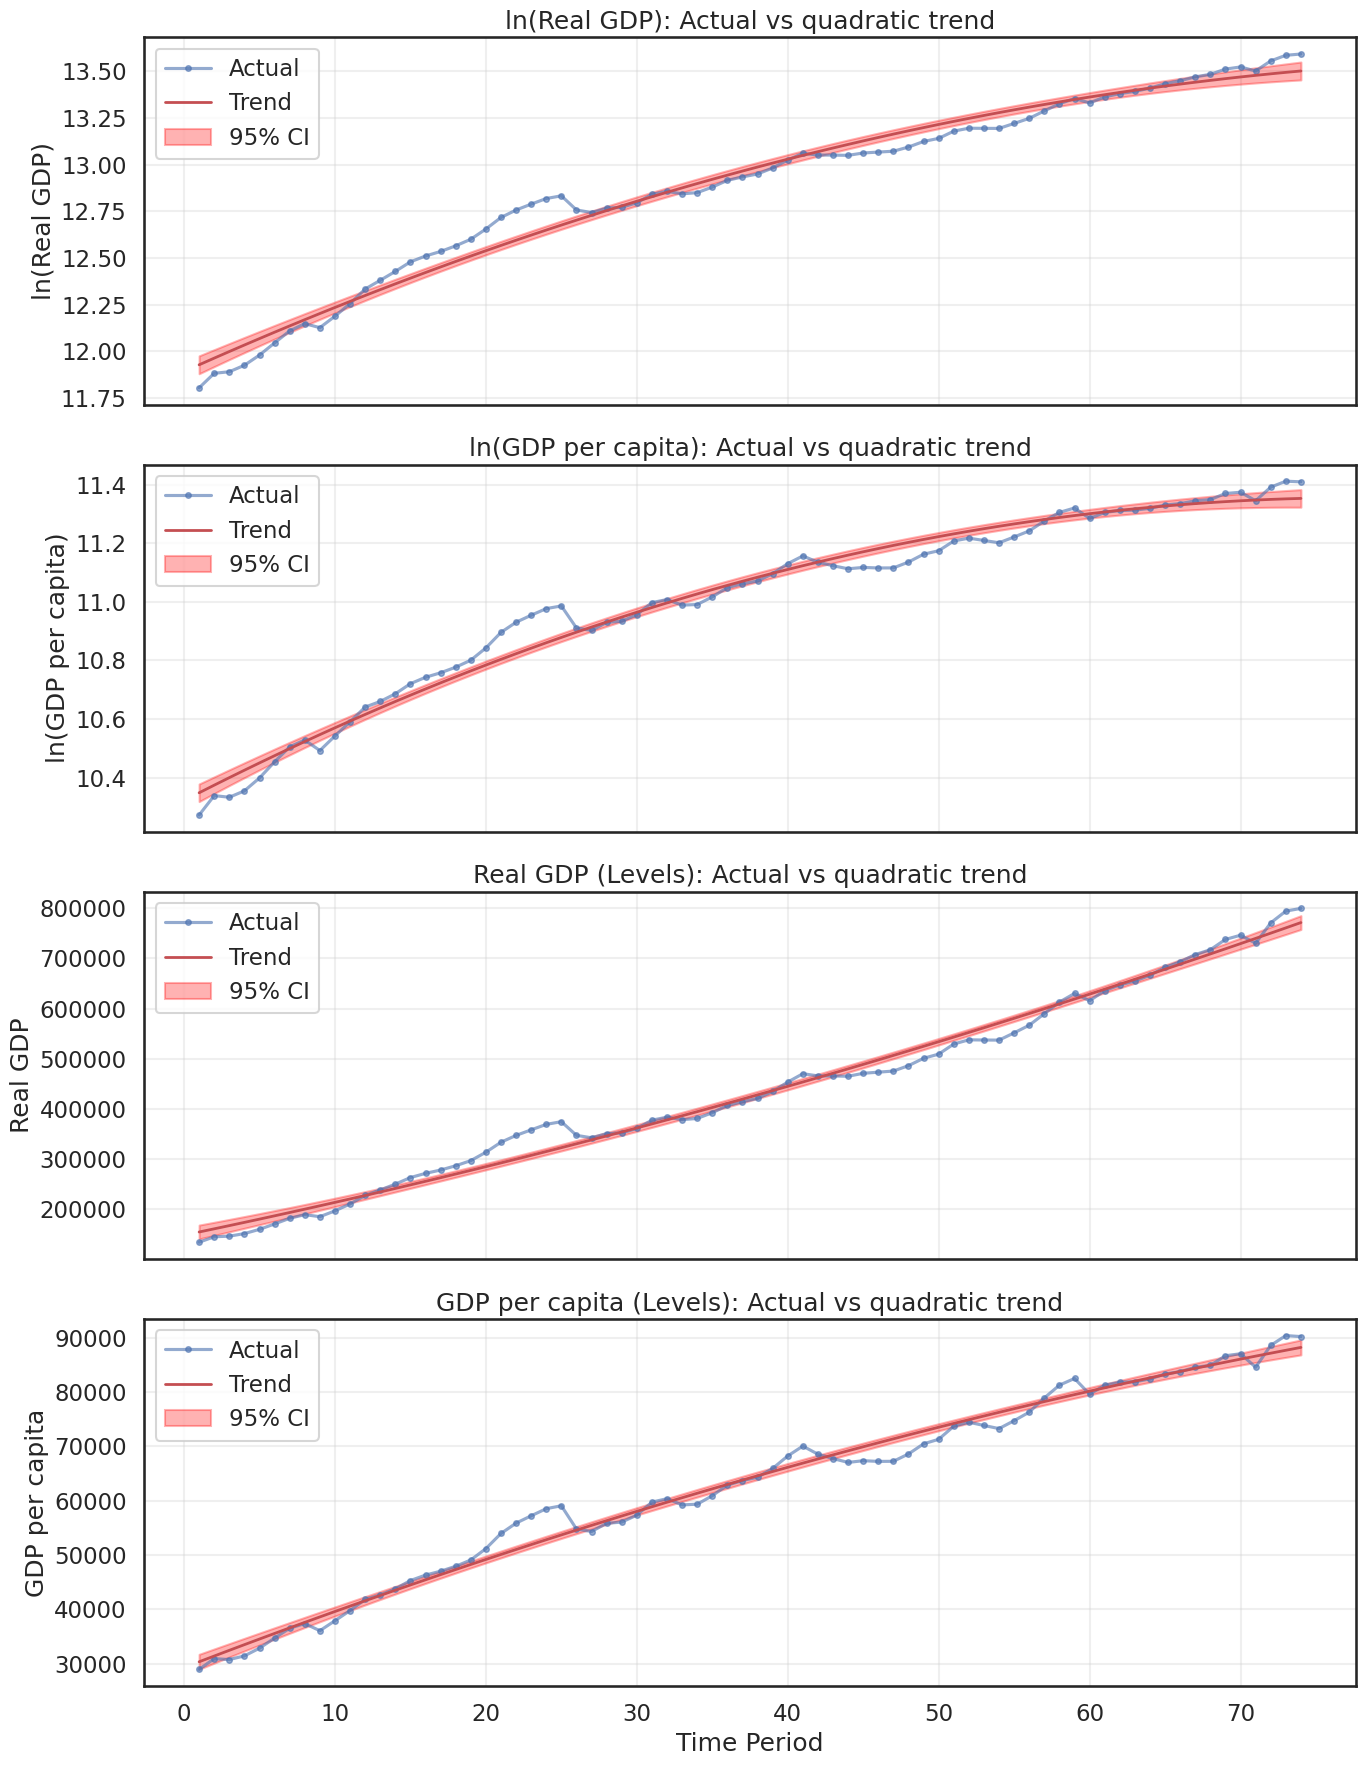

In [ ]:
# Visualizing the fitted trends (quadratic)
# Including the title, x and y labels, legend, confidence intervals
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

# 1. ln(Real GDP)
axes[0].plot(x2, ln_Y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[0].plot(x2, fitted_ln_Y, 'r-', linewidth=2, label='Trend') # plotting the fitted trend line in red
axes[0].fill_between(x2, ci_band_ln_Y_lower, ci_band_ln_Y_upper,
                     alpha=0.3, color='red', label='95% CI') # shading the 95% confidence interval around the fitted trend
axes[0].set_title('ln(Real GDP): Actual vs quadratic trend') # setting the title of the first subplot
axes[0].set_ylabel('ln(Real GDP)') # labelling the y-axis
axes[0].legend() # to display the legend
axes[0].grid(alpha=0.3) # adding a light grid for readability

# 2. ln(GDP per capita)
axes[1].plot(x2, ln_y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[1].plot(x2, fitted_ln_y, 'r-', linewidth=2, label='Trend')
axes[1].fill_between(x2, ci_band_ln_y_lower, ci_band_ln_y_upper,
                     alpha=0.3, color='red', label='95% CI')
axes[1].set_title('ln(GDP per capita): Actual vs quadratic trend')
axes[1].set_ylabel('ln(GDP per capita)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Real GDP (levels)
axes[2].plot(x2, Y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[2].plot(x2, fitted_Y, 'r-', linewidth=2, label='Trend')
axes[2].fill_between(x2, ci_band_Y_lower, ci_band_Y_upper,
                     alpha=0.3, color='red', label='95% CI')
axes[2].set_title('Real GDP (Levels): Actual vs quadratic trend')
axes[2].set_ylabel('Real GDP')
axes[2].legend()
axes[2].grid(alpha=0.3)

# 4. GDP per capita (levels)
axes[3].plot(x2, y, 'o-', alpha=0.6, label='Actual', markersize=4)
axes[3].plot(x2, fitted_y, 'r-', linewidth=2, label='Trend')
axes[3].fill_between(x2, ci_band_y_lower, ci_band_y_upper,
                     alpha=0.3, color='red', label='95% CI')
axes[3].set_title('GDP per capita (Levels): Actual vs quadratic trend')
axes[3].set_xlabel('Time Period')
axes[3].set_ylabel('GDP per capita')
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Time Series of main variables

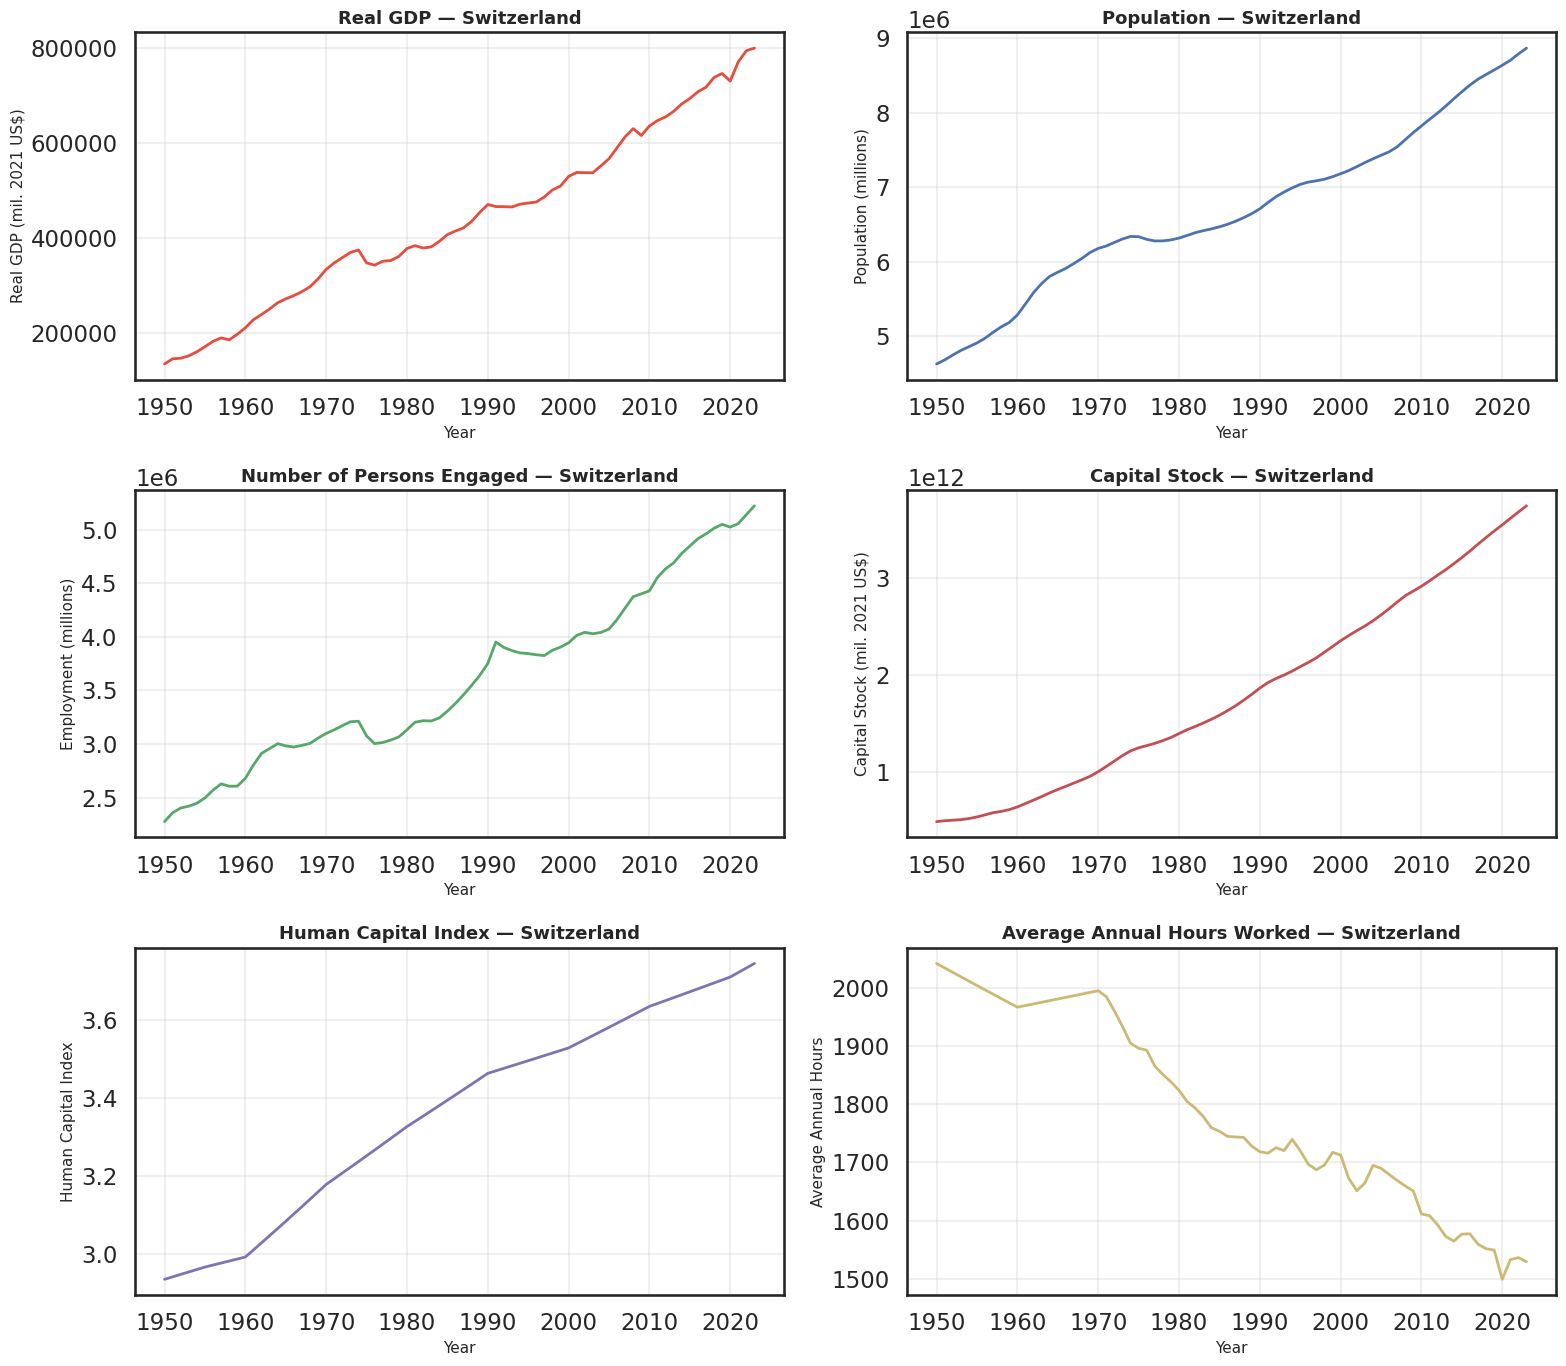

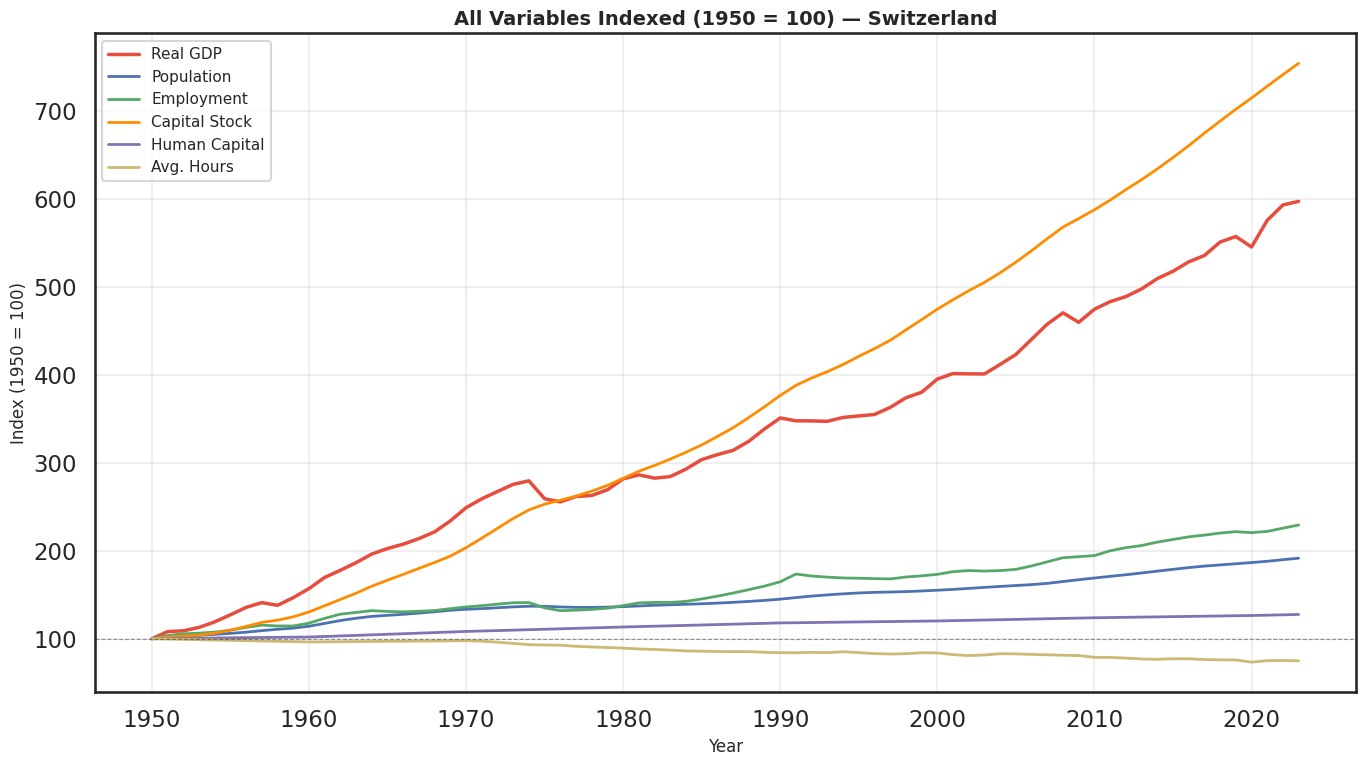

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Obtaining the Time series of main variables - Real GDP, Population, Employment, Capital Stock, Human Capital Index and Average Annual Hours
# Extracting year from the data
year = data["year"].values # takes values (year) from the 'year' column. Converts it into a NumPy array and stores it in year

# Creating figures with subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Plot 1: Real GDP (Y)
axes[0, 0].plot(year, Y, linewidth=2, color='#E74C3C')
axes[0, 0].set_xlabel('Year', fontsize=11) # labelling the x axis
axes[0, 0].set_ylabel('Real GDP (mil. 2021 US$)', fontsize=11) # labelling the y axis
axes[0, 0].set_title('Real GDP — Switzerland', fontsize=13, fontweight='bold') # setting the title for the first plot
axes[0, 0].grid(True, alpha=0.3) # adding a light grid for readability

# Plot 2: Population (N)
axes[0, 1].plot(year, N, linewidth=2, color='#4C72B0')
axes[0, 1].set_xlabel('Year', fontsize=11)
axes[0, 1].set_ylabel('Population (millions)', fontsize=11)
axes[0, 1].set_title('Population — Switzerland', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Employment (L)
axes[1, 0].plot(year, L, linewidth=2, color='#55A868')
axes[1, 0].set_xlabel('Year', fontsize=11)
axes[1, 0].set_ylabel('Employment (millions)', fontsize=11)
axes[1, 0].set_title('Number of Persons Engaged — Switzerland', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Capital Stock (K)
axes[1, 1].plot(year, K, linewidth=2, color='#C44E52')
axes[1, 1].set_xlabel('Year', fontsize=11)
axes[1, 1].set_ylabel('Capital Stock (mil. 2021 US$)', fontsize=11)
axes[1, 1].set_title('Capital Stock — Switzerland', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Plot 5: Human Capital Index (HC)
axes[2, 0].plot(year, HC, linewidth=2, color='#8172B3')
axes[2, 0].set_xlabel('Year', fontsize=11)
axes[2, 0].set_ylabel('Human Capital Index', fontsize=11)
axes[2, 0].set_title('Human Capital Index — Switzerland', fontsize=13, fontweight='bold')
axes[2, 0].grid(True, alpha=0.3)

# Plot 6: Average Annual Hours (AVH)
axes[2, 1].plot(year, AVH, linewidth=2, color='#CCB974')
axes[2, 1].set_xlabel('Year', fontsize=11)
axes[2, 1].set_ylabel('Average Annual Hours', fontsize=11)
axes[2, 1].set_title('Average Annual Hours Worked — Switzerland', fontsize=13, fontweight='bold')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Second figure: Plotting all variables indexed to 1950 = 100 (relative to 1950) for Switzerland
fig2, ax = plt.subplots(figsize=(14, 8))

base_year_idx = 0  # setting the base year to 1950 (1950 is assumed to be the first observation)
Y_indexed = (Y / Y[base_year_idx]) * 100
N_indexed = (N / N.iloc[base_year_idx]) * 100
L_indexed = (L / L.iloc[base_year_idx]) * 100
K_indexed = (K / K.iloc[base_year_idx]) * 100
HC_indexed = (HC / HC.iloc[base_year_idx]) * 100
AVH_indexed = (AVH / AVH.iloc[base_year_idx]) * 100

ax.plot(year, Y_indexed, linewidth=2.5, label='Real GDP', color='#E74C3C')  # plotting indexed real GDP
ax.plot(year, N_indexed, linewidth=2, label='Population', color='#4C72B0') # plotting indexed population
ax.plot(year, L_indexed, linewidth=2, label='Employment', color='#55A868') # plotting indexed employment (number of workers)
ax.plot(year, K_indexed, linewidth=2, label='Capital Stock', color='#FF8C00')  # plotting indexed capital stock
ax.plot(year, HC_indexed, linewidth=2, label='Human Capital', color='#8172B3') # plotting indexed human capital index
ax.plot(year, AVH_indexed, linewidth=2, label='Avg. Hours', color='#CCB974') # plotting indexed average annual number of hours worked

ax.set_xlabel('Year', fontsize=12) # labelling x axis
ax.set_ylabel('Index (1950 = 100)', fontsize=12) # labelling y axis
ax.set_title('All Variables Indexed (1950 = 100) — Switzerland', fontsize=14, fontweight='bold') # setting the title for the last graph
ax.legend(fontsize=11, loc='best') # to display the legend
ax.grid(True, alpha=0.3) # adding a light grid for readability
ax.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.4) # adding a horizontal reference line at the index level 100 to highlight the base level for comparision

plt.tight_layout()
plt.show()

# TASK B: Extract TFP measure

## $\alpha$ = 0.3

Construct TFP as the Solow residual
There are 4 ways to calculate A:

$Y = A K^\alpha L^{(1-\alpha)}$

1. Neutral TFP : $A = \frac{Y}{K^\alpha \times L^{(1-\alpha)}}$

$Y =  K^\alpha (AL)^{(1-\alpha)}$

2. Labour-augmenting TFP : $A = ({\frac{Y}{K^\alpha}})^\frac{1}{{(1-\alpha)}} \times \frac{1}{L}$

$Y = A \times (K)^\alpha (HC \times L)^{(1-\alpha)}$

3. Human-capital adjusted L : $A = \frac{Y}{(K^\alpha)} \times \frac{1}{(HC*L)^{(1-\alpha)}}$

$Y = A (K)^\alpha (AVH \times HC \times L)^{(1-\alpha)}$

4. HC and AVH adjusted L : $A = \frac{Y}{(K^\alpha)} \times \frac{1}{(AVH * HC *L)^{(1-\alpha)}}$




where
Y = Real GDP at constant 2021 national prices (in mil. 2021US$)

L = Number of persons engaged (in millions)

K = Capital stock at constant 2021 national prices (in mil. 2021US$)

HC = Human capital index, based on years of schooling and returns to education; see Human capital in PWT9.

AVH = Average annual hours worked by persons engaged.

We will plot all four to check for consistency, but proceed with the Human-capital adjusted definition since it fits most in the context.

In [ ]:
alpha = 0.3  # share of total output that goes capital - benchmark value from literature
# Extracting a measure for TFP
# TFP as residuals
# TFP calculations with hours adjustment

# 1. Neutral TFP
TFP_1 = Y / ((K**alpha) * ((L)**(1-alpha))) # calculated using the neutral production function

# 2. Labour-augmenting TFP
TFP_2 = (Y / (K**alpha))**(1/(1-alpha)) *(1/ (L)) # calculated using the labour-augmented production function

# 3. Human-capital augmenting L
TFP_3 = Y / ((K**alpha) * ((L*HC)**(1-alpha))) # calculated using the human-capital augmented labour production function

# 4. HC and AVH adjusted L
TFP_4 = Y / ((K**alpha) * ((L * HC * AVH)**(1-alpha))) # calculated using the human-capital augmented and average annual hours worked adjusted labour production function


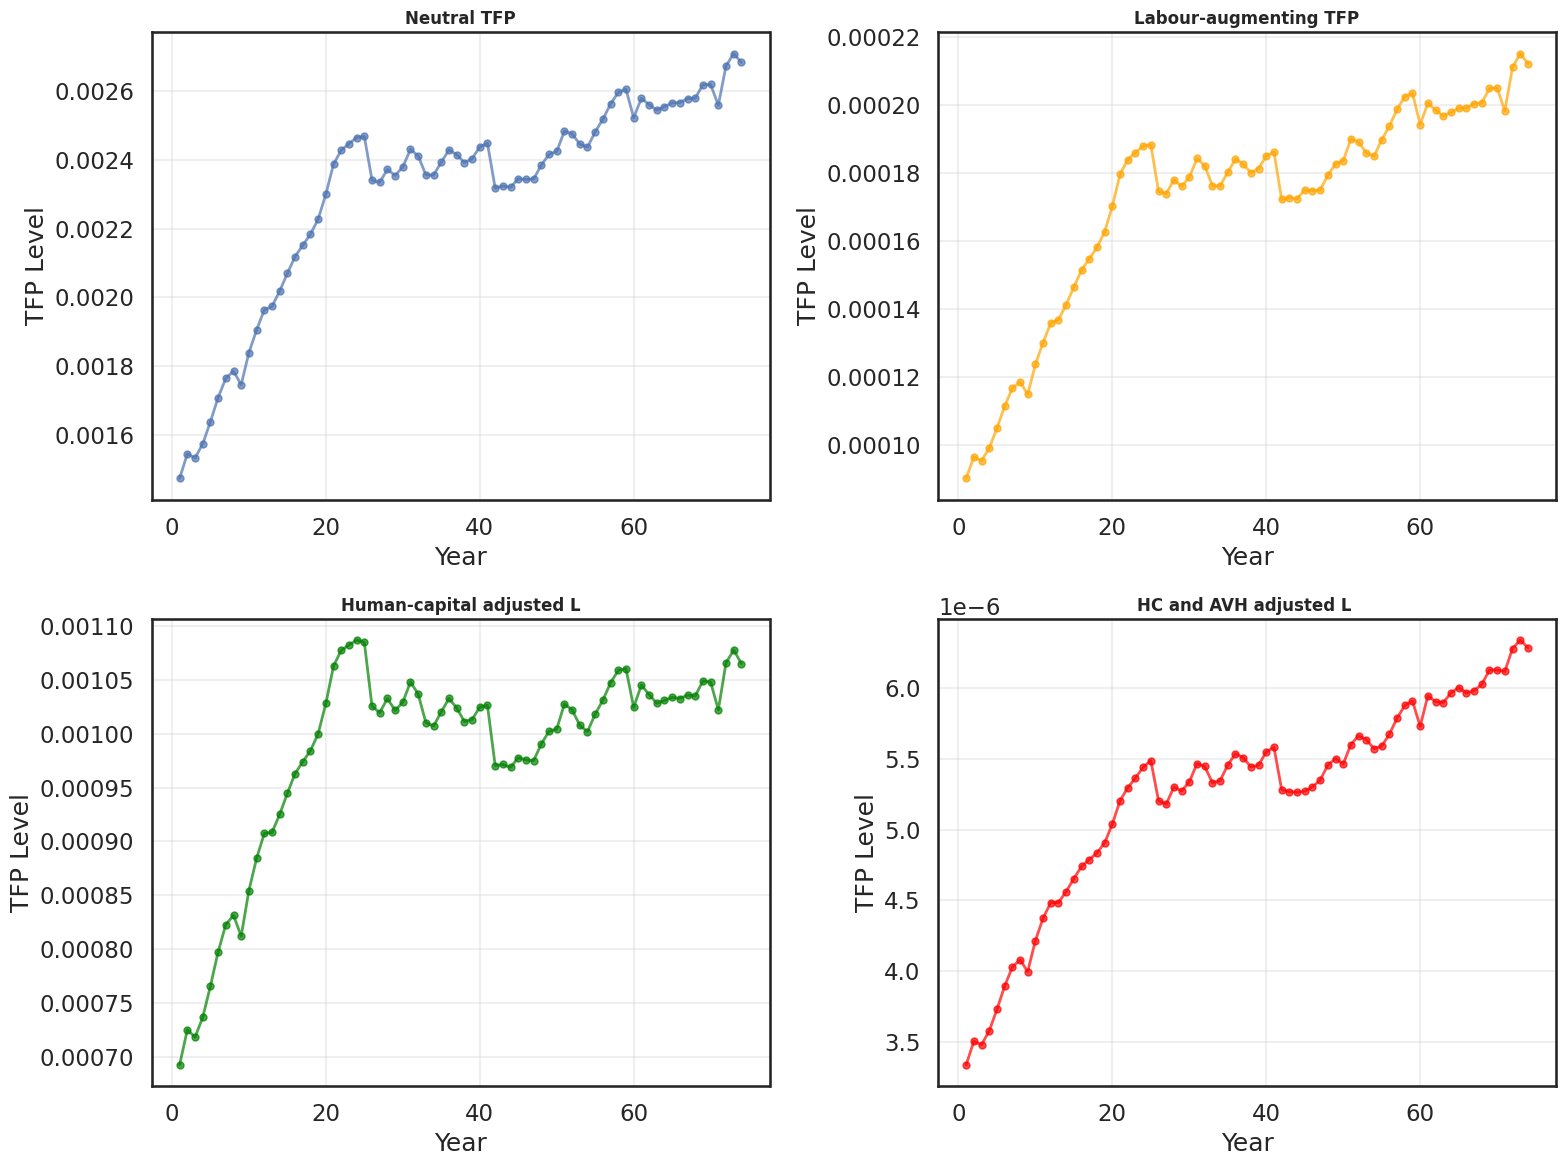

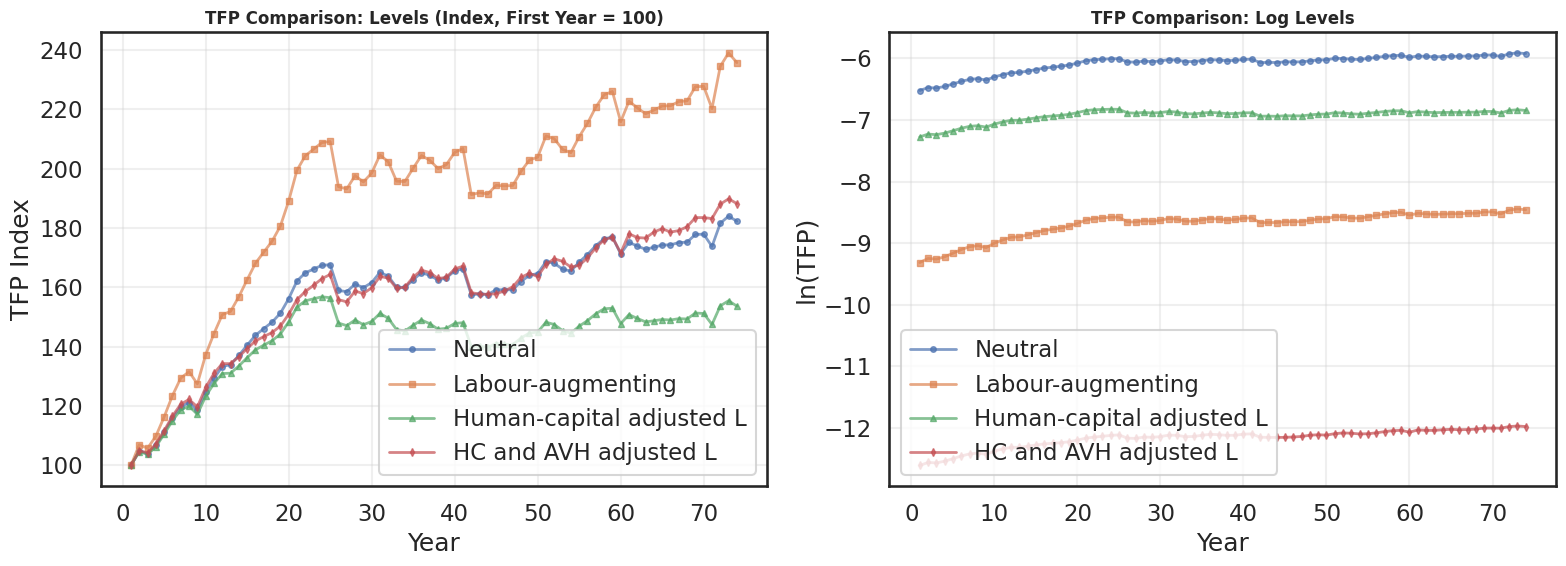

In [ ]:
# Calculating the log TFP for all four measures
ln_TFP_1 = np.log(TFP_1) # transforming TFPs into log form
ln_TFP_2 = np.log(TFP_2)
ln_TFP_3 = np.log(TFP_3)
ln_TFP_4 = np.log(TFP_4)

# Creating visualizations of different TFP calculations (subplots)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Neutral TFP
axes[0, 0].plot(x2, TFP_1, 'o-', alpha=0.7, linewidth=2, markersize=5) # plotting neutral TFP
axes[0, 0].set_title('Neutral TFP', fontsize=12, fontweight='bold') # setting the title of the first subplot
axes[0, 0].set_xlabel('Year') # labelling x axis
axes[0, 0].set_ylabel('TFP Level') # labelling y axis
axes[0, 0].grid(alpha=0.3) # adding a light grid for readability

# Plot 2: Labour-augmenting TFP
axes[0, 1].plot(x2, TFP_2, 'o-', alpha=0.7, linewidth=2, markersize=5, color='orange')
axes[0, 1].set_title('Labour-augmenting TFP', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('TFP Level')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Human-capital adjusted L
axes[1, 0].plot(x2, TFP_3, 'o-', alpha=0.7, linewidth=2, markersize=5, color='green')
axes[1, 0].set_title('Human-capital adjusted L', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('TFP Level')
axes[1, 0].grid(alpha=0.3)

# Plot 4: HC and AVH adjusted L
axes[1, 1].plot(x2, TFP_4, 'o-', alpha=0.7, linewidth=2, markersize=5, color='red')
axes[1, 1].set_title('HC and AVH adjusted L ', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('TFP Level')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Comparison plots: All TFP measures plotted together (normalized to 100 in first year (1950))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Levels comparison (normalized TFP)
TFP_1_norm = 100 * TFP_1 / TFP_1[0] # normalizing TFP to ensure accurate comparision
TFP_2_norm = 100 * TFP_2 / TFP_2[0]
TFP_3_norm = 100 * TFP_3 / TFP_3[0]
TFP_4_norm = 100 * TFP_4 / TFP_4[0]

ax1.plot(x2, TFP_1_norm, 'o-', alpha=0.7, linewidth=2, label='Neutral', markersize=4) # plotting TFP_1 with circle markers at each data point connected by a line
ax1.plot(x2, TFP_2_norm, 's-', alpha=0.7, linewidth=2, label='Labour-augmenting', markersize=4)
ax1.plot(x2, TFP_3_norm, '^-', alpha=0.7, linewidth=2, label='Human-capital adjusted L', markersize=4)
ax1.plot(x2, TFP_4_norm, 'd-', alpha=0.7, linewidth=2, label='HC and AVH adjusted L', markersize=4)
ax1.set_title('TFP Comparison: Levels (Index, First Year = 100)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('TFP Index')
ax1.legend()
ax1.grid(alpha=0.3)

# Log comparison
ax2.plot(x2, ln_TFP_1, 'o-', alpha=0.7, linewidth=2, label='Neutral', markersize=4)
ax2.plot(x2, ln_TFP_2, 's-', alpha=0.7, linewidth=2, label='Labour-augmenting', markersize=4)
ax2.plot(x2, ln_TFP_3, '^-', alpha=0.7, linewidth=2, label='Human-capital adjusted L', markersize=4)
ax2.plot(x2, ln_TFP_4, 'd-', alpha=0.7, linewidth=2, label='HC and AVH adjusted L', markersize=4)
ax2.set_title('TFP Comparison: Log Levels', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('ln(TFP)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Robustness checks for alpha values

Test robustness with different alpha values as required

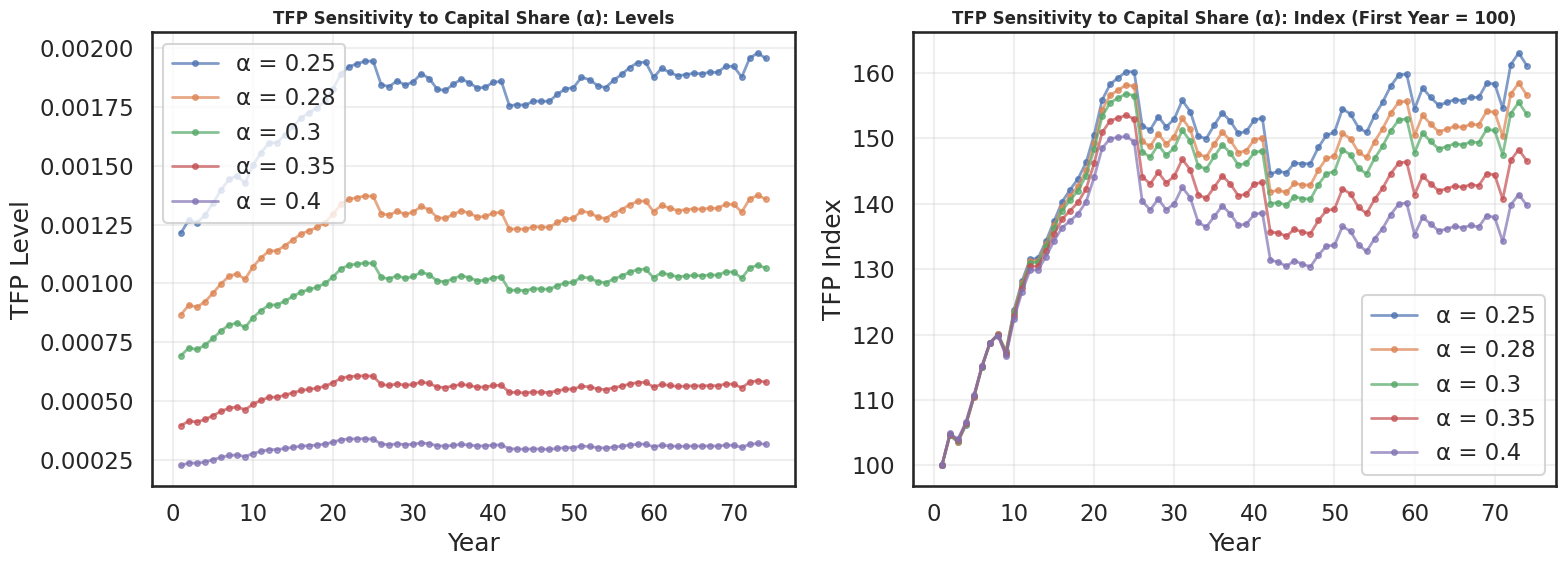

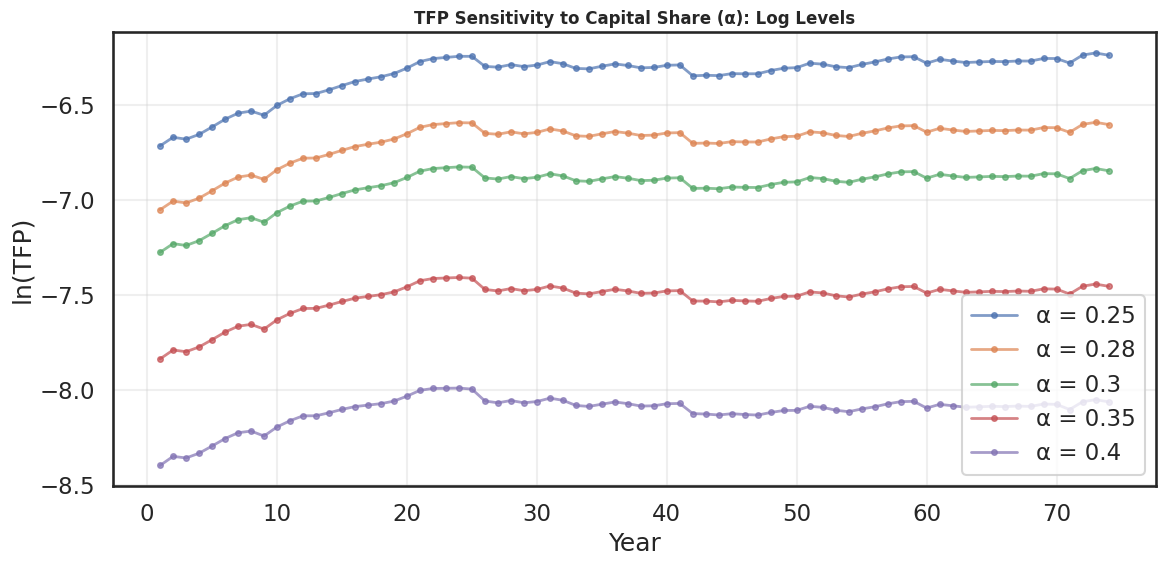

In [ ]:
# Robustness checks with different alpha values using TFP calculated from human-capital adjusted (labour) production function
# Examples of alpha values
alpha_values = [0.25, 0.28, 0.30, 0.35, 0.40] # defining a list of alpha values considered for the robustness check

# Creating a dictionary to store TFP for each alpha
TFP_dict = {}

# Loop over all example alpha values in alpha_values and calculate TFP for each value
for alpha_test in alpha_values:
    TFP_dict[alpha_test] = (Y / ((K**alpha_test) * ((L*HC)**(1-alpha_test))))

# Defining subplots to make the graphs for TFP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: TFP Levels
for alpha_test in alpha_values: # loops over different capital share values in the list alpha_values
    ax1.plot(x2, TFP_dict[alpha_test], 'o-', alpha=0.7, linewidth=2,
             label=f'α = {alpha_test}', markersize=4) # plots the TFP levels as labelled lines for each alpha value in alpha_values; includes circle markers for each data point and connects them with a solid line

ax1.set_title('TFP Sensitivity to Capital Share (α): Levels', fontsize=12, fontweight='bold') # setting the title for the subplot
ax1.set_xlabel('Year') # labelling x axis
ax1.set_ylabel('TFP Level') # labelling y axis
ax1.legend() # to display the legend
ax1.grid(alpha=0.3) # adding a light grid for readability

# Plot 2: TFP Normalized (Index, first year = 100)
for alpha_test in alpha_values: # loops over different capital share values in the list alpha_values
    TFP_norm = 100 * TFP_dict[alpha_test] / TFP_dict[alpha_test][0] # normalizes TFP
    ax2.plot(x2, TFP_norm, 'o-', alpha=0.7, linewidth=2,
             label=f'α = {alpha_test}', markersize=4) # plots the normalized TFP levels as labelled lines for each alpha value in alpha_values; includes circle markers for each data point and connects them with a solid line


ax2.set_title('TFP Sensitivity to Capital Share (α): Index (First Year = 100)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('TFP Index')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Log plot for growth rate comparison (different alpha values in same plot)
fig, ax = plt.subplots(figsize=(12, 6))

for alpha_test in alpha_values: # loops over different capital share values in the list alpha_values
    ln_TFP = np.log(TFP_dict[alpha_test]) # transforms TFP for each alpha value into its log form
    ax.plot(x2, ln_TFP, 'o-', alpha=0.7, linewidth=2,
            label=f'α = {alpha_test}', markersize=4) # plots the natural log of TFP as labelled lines for each alpha value in alpha_values; includes circle markers for each data point and connects them with a solid line

ax.set_title('TFP Sensitivity to Capital Share (α): Log Levels', fontsize=12, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('ln(TFP)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

So, TFP calculation is robust to choice of alpha, especially in levels.

#TASK C: Growth accounting

## $Y = A \times (K)^\alpha (HC * L)^{(1-\alpha)}$
Growth accounting for sub-periods using formula:
$ 1 = \frac {log A_t - log A_{t-n}}{log Y_t - log Y_{t-n}} + \alpha \times \frac {log K_t - log K_{t-n}}{log Y_t - log Y_{t-n}} +  (1-\alpha) \times  \frac {log (HC \times L)_t - log (HC \times L)_{t-n}}{log Y_t - log Y_{t-n}}$


      Period  Total_Growth  K_contrib  H_contrib  A_contrib  Sum
0  1950-1974    102.826497   0.292508   0.286827   0.420665  1.0
1  1975-1992     29.363015   0.510106   0.690688  -0.200794  1.0
2  1993-2006     23.793159   0.410802   0.288797   0.300401  1.0
3  2007-2023     26.618657   0.384383   0.602009   0.013608  1.0


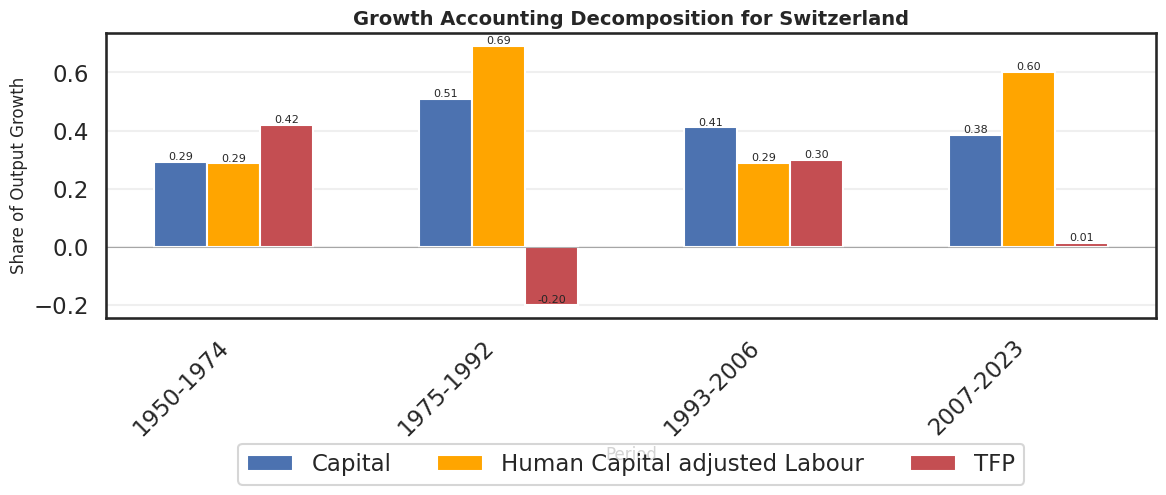

In [ ]:
# Growth accounting for sub-periods
# Defining alpha as 1/3 based on macroeconomic literature
# alpha = capital's share of income

alpha = 1/3
H = HC * L  # Total human capital-adjusted labour input (obtained by multiplying HC and L)

# Initializing an empty list to store results for each period
accounting_results = []

# Defining the subperiods correctly as a list of tuples for analysis
periods = [
    (1950, 1974),
    (1975, 1992),
    (1993, 2006),
    (2007, 2023),
]

# Creating a loop to run growth accounting separately for each time period
for period_start, period_end in periods: # sub-periods as defined before

    # indices for start and end years
    start_idx = np.where(year == period_start)[0] # obtaining an array of indices of the start and end years of each sub period
    end_idx = np.where(year == period_end)[0]

    # skipping the subperiod if either year (start or end) is missing
    if len(start_idx) == 0 or len(end_idx) == 0:
        continue

    start_idx = start_idx[0] # extracting the actual integer index from the array returned by np.where()
    end_idx = end_idx[0]

    # computing the log changes over each subperiod for each variable Y, K and H
    log_change_Y = np.log(Y[end_idx] / Y[start_idx]) # obtaining the growth rate of Y (real GDP)
    log_change_K = np.log(K[end_idx] / K[start_idx]) # obtaining the growth rate of K (capital)
    log_change_H = np.log(H[end_idx] / H[start_idx]) # obtaining the growth rate of H (human capital-adjusted labour input)

    # Computing the growth rate of TFP
    # TFP is the residual
    log_change_A = log_change_Y - alpha * log_change_K - (1-alpha) * log_change_H

    # Contributions to growth (in percentage points)
    contrib_K_pp = alpha * log_change_K  # computing the contributions of capital to GDP growth
    contrib_H_pp = (1-alpha)* log_change_H  # computing the contributions of human capital-adjusted labour input to GDP growth
    contrib_A_pp = log_change_A  # computing the contributions of TFP to GDP growth

    # Contributions as shares of total growth (dividing each contribution by total output growth)
    contrib_K = contrib_K_pp / log_change_Y # contributions as shares of total growth of all variables sums upto 1
    contrib_H = contrib_H_pp / log_change_Y
    contrib_A = contrib_A_pp / log_change_Y

    accounting_results.append({    # storing our results in the empty list accounting_results created before
        "Period": f"{period_start}-{period_end}",
        "Total_Growth": log_change_Y * 100,
        "K_contrib": contrib_K,
        "H_contrib": contrib_H,
        "A_contrib": contrib_A,
        "Sum": contrib_K + contrib_H + contrib_A # sum of contributions of all variables K, H, A
    })

# Converting to DataFrame (table format) for easy viewing
import pandas as pd
results_df = pd.DataFrame(accounting_results) # converting accounting_results into a dataframe and storing it in results_df
print(results_df) # displaying the dataframe

# Creating grouped bar plot for analysis
import matplotlib.pyplot as plt
import numpy as np

# Extracting data and storing them in variables for plotting
periods = results_df["Period"]
K_contrib = results_df["K_contrib"]
H_contrib = results_df["H_contrib"]
A_contrib = results_df["A_contrib"]

# Setting up positions for bars
x = np.arange(len(periods)) # creating an array
width = 0.2  # Width of each individual bar

fig, ax = plt.subplots(figsize=(12, 6)) # plotting a graph of size 12 x 6

# Creating grouped bars (shifted left, center, right for separation)
bars1 = ax.bar(x - 1*width, K_contrib, width, label='Capital', color='#4C72B0') # bars showing capital contribution
bars2 = ax.bar(x , H_contrib, width, label='Human Capital adjusted Labour', color='#FFA500') # bars showing human capital adjusted labour contribution
bars3 = ax.bar(x + 1*width, A_contrib, width, label='TFP', color='#C44E52') # bars showing TFP contribution

# Adding value labels on bars
def add_value_labels(bars): # defining a function to add numerical value labels on top of each bar
    for bar in bars:
        height = bar.get_height() # defining height variable to get the bar height
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', # Formatting to 2 decimal places
                ha='center', va='bottom', fontsize=8)

add_value_labels(bars1) # applying value labels to each group of bars
add_value_labels(bars2)
add_value_labels(bars3)

# Formatting of the graph
ax.set_xlabel('Period', fontsize=12) # labelling x axis as 'period'
ax.set_ylabel('Share of Output Growth', fontsize=12) # labelling y axis as 'share of output growth'
ax.set_title('Growth Accounting Decomposition for Switzerland', fontsize=14, fontweight='bold') # setting the title
ax.set_xticks(x)
ax.set_xticklabels(periods, rotation=45, ha='right') # labelling the subperiods
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=3) # to display the legend
ax.axhline(0, color='black', linewidth=0.8, alpha=0.3) # adding a horizontal reference line at 0.0
ax.grid(axis='y', alpha=0.3) # adding a light grid for readability

plt.tight_layout() # adjusting spacing
plt.show()

## $Y = A \times (K)^\alpha (L)^{(1-\alpha)}$
## Robustness check for growth accounting exercise
$ 1 = \frac {log A_t - log A_{t-n}}{log Y_t - log Y_{t-n}} + \alpha \times \frac {log K_t - log K_{t-n}}{log Y_t - log Y_{t-n}} +  (1-\alpha) \times  \frac {log (L)_t - log (L)_{t-n}}{log Y_t - log Y_{t-n}}$


      Period  Total_Growth  K_contrib  L_contrib  A_contrib  Sum
0  1950-1974    102.826497   0.292508   0.223372   0.484120  1.0
1  1975-1992     29.363015   0.510106   0.539147  -0.049253  1.0
2  1993-2006     23.793159   0.410802   0.202229   0.386968  1.0
3  2007-2023     26.618657   0.384383   0.504903   0.110714  1.0


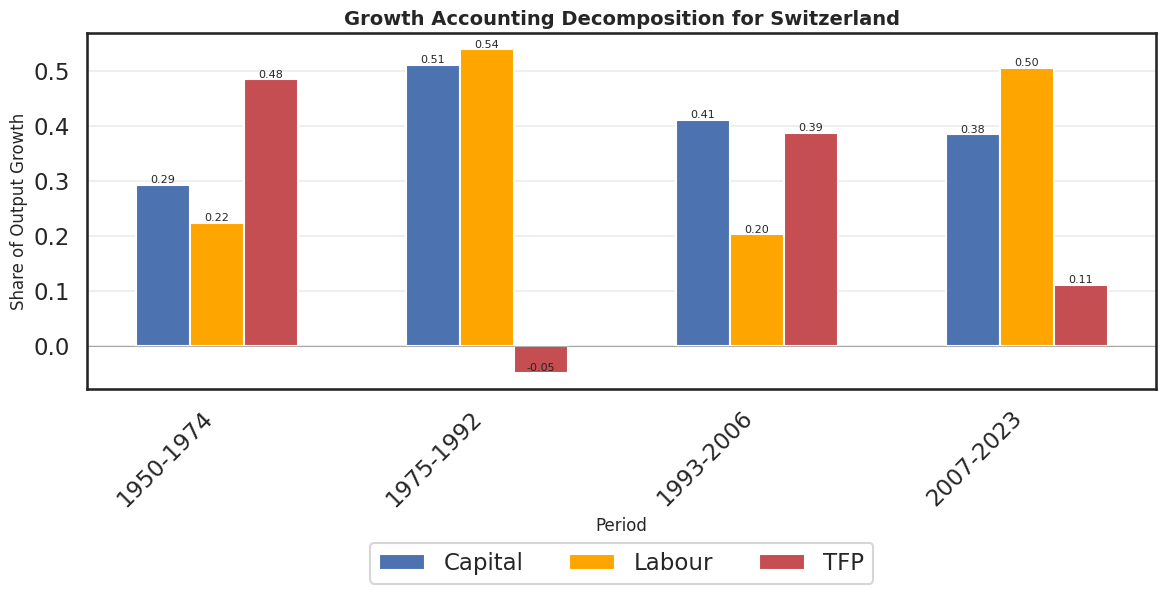

In [ ]:
# Extract year from data
year = data["year"].values # takes values (year) from the 'year' column. Converts it into a NumPy array and stores it in year
alpha = 1/3 # alpha = capital's share of income; based on macroeconomic literature

# Initializing an empty list to store results for each period
accounting_results = []

# Defining the subperiods correctly as a list of tuples for analysis
periods = [
    (1950, 1974),
    (1975, 1992),
    (1993, 2006),
    (2007, 2023),
]

# Creating a loop to run growth accounting separately for each time period
for period_start, period_end in periods: # sub-periods as defined before

    # indices for start and end years
    start_idx = np.where(year == period_start)[0] # obtaining an array of indices of the start and end years of each sub period
    end_idx = np.where(year == period_end)[0]

    # skipping the subperiod if either year (start or end) is missing
    if len(start_idx) == 0 or len(end_idx) == 0:
        continue

    start_idx = start_idx[0] # extracting the actual integer index from the array returned by np.where()
    end_idx = end_idx[0]

    # computing the log changes over each subperiod for each variable Y, K and H
    log_change_Y = np.log(Y[end_idx] / Y[start_idx])
    log_change_K = np.log(K[end_idx] / K[start_idx])
    log_change_L = np.log(L[end_idx] / L[start_idx])

    # Computing the growth rate of TFP
    # TFP is the residual
    log_change_A = log_change_Y - alpha * log_change_K - (1-alpha) * log_change_L

    # Contributions to growth (in percentage points)
    contrib_K_pp = alpha * log_change_K
    contrib_L_pp = (1-alpha)* log_change_L  # Human capital enters multiplicatively
    contrib_A_pp = log_change_A

    # Contributions as shares of total growth
    contrib_K = contrib_K_pp / log_change_Y
    contrib_L = contrib_L_pp / log_change_Y
    contrib_A = contrib_A_pp / log_change_Y

    accounting_results.append({   # storing our results in the empty list accounting_results created before
        "Period": f"{period_start}-{period_end}",
        "Total_Growth": log_change_Y * 100,
        "K_contrib": contrib_K,
        "L_contrib": contrib_L,
        "A_contrib": contrib_A,
        "Sum": contrib_K + contrib_L + contrib_A
    })

# Converting to DataFrame (table format) for easy viewing
import pandas as pd
results_df = pd.DataFrame(accounting_results) # converting accounting_results into a dataframe and storing it in results_df
print(results_df) # displaying the dataframe

# Creating grouped bar plot for analysis
import matplotlib.pyplot as plt
import numpy as np

# Extracting data and storing them in variables for plotting
periods = results_df["Period"]
K_contrib = results_df["K_contrib"]
H_contrib = results_df["L_contrib"]
A_contrib = results_df["A_contrib"]

# Setting up positions for bars
x = np.arange(len(periods))
width = 0.2  # Width of each bar

fig, ax = plt.subplots(figsize=(12, 6))

# Creating grouped bars (shifted left, center, right for separation)
bars1 = ax.bar(x - 1*width, K_contrib, width, label='Capital', color='#4C72B0')
bars2 = ax.bar(x , H_contrib, width, label='Labour', color='#FFA500')
bars3 = ax.bar(x + 1*width, A_contrib, width, label='TFP', color='#C44E52')

# Add value labels on bars
def add_value_labels(bars): # defining a function to add numerical value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=8)

add_value_labels(bars1) # applying value labels to each group of bars
add_value_labels(bars2)
add_value_labels(bars3)

# Formatting
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Share of Output Growth', fontsize=12)
ax.set_title('Growth Accounting Decomposition for Switzerland', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods, rotation=45, ha='right')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=3)
plt.tight_layout()
ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# TASK D : LABOUR PRODUCTIVITY

In [ ]:
# Constructing a series for labour productivity i.e., GDP per worker
# Re-assigning L to the correct Labour data before calculating labour productivity
L = data["emp"]

# Constructing labour productivity
labour_productivity = Y / (L) # GDP divided by the No. of employees
labour_productivity_2 = Y/ (L*HC) # GDP divided by the No. of employees multiplied by the human capital index
ln_labour_productivity = np.log(Y / (L)) # transforming labour_productivity into log form
ln_labour_productivity_2 = np.log(Y / (L*HC)) # transforming labour_productivity_2 into log form

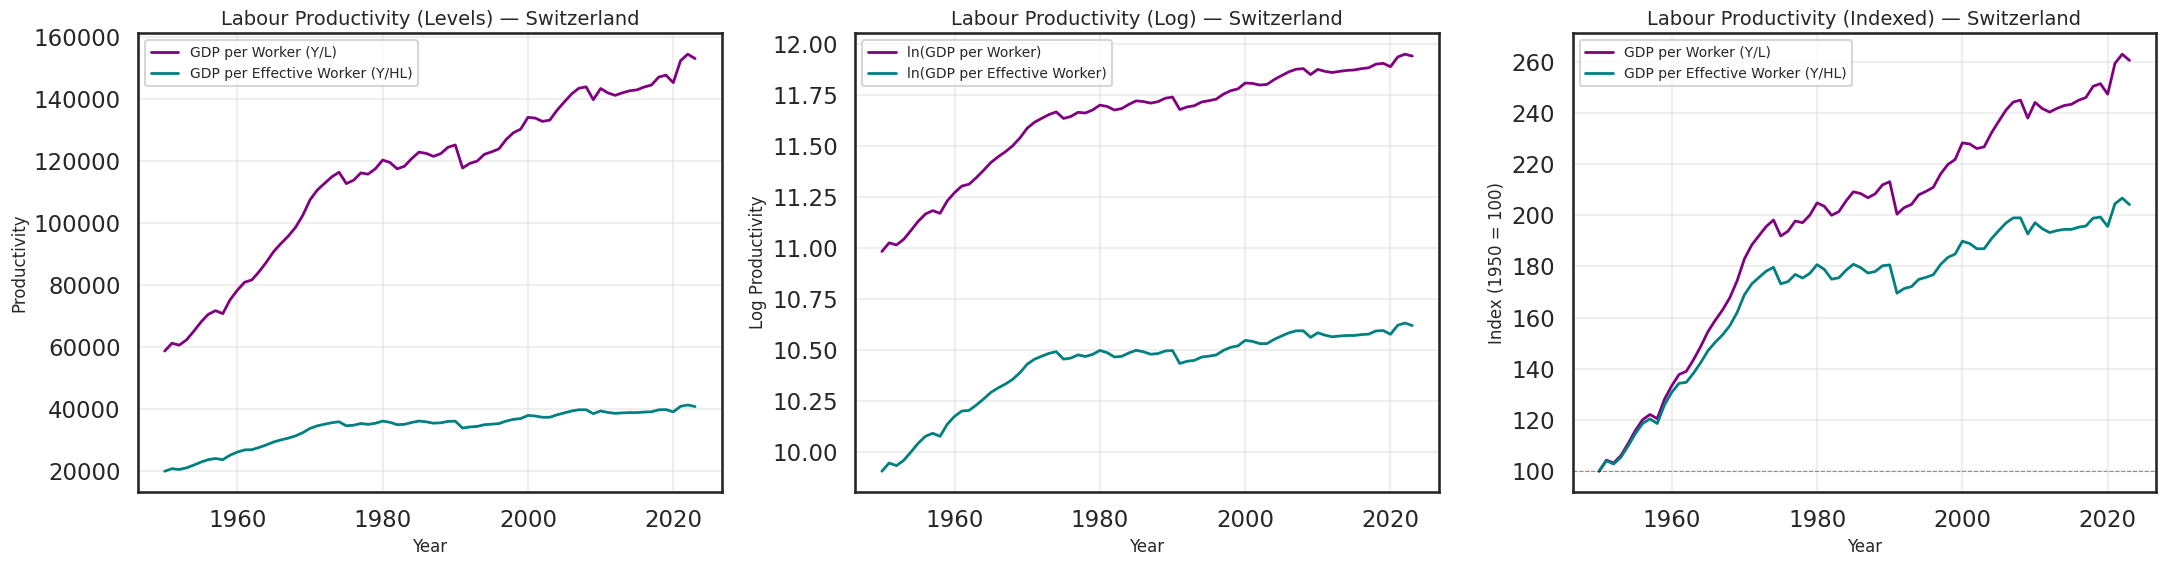

In [ ]:
# Plotting labour productivity over time
fig, axes = plt.subplots(1, 3, figsize=(22, 6)) # plotting subplots of size 22 x 6

# Plot 1: Levels
axes[0].plot(year, labour_productivity, linewidth=2, color='purple', label='GDP per Worker (Y/L)') # Plotting GDP per worker
axes[0].plot(year, labour_productivity_2, linewidth=2, color='teal', label='GDP per Effective Worker (Y/HL)') # Plotting GDP per effective worker
axes[0].set_xlabel('Year', fontsize=12) # labelling x axis
axes[0].set_ylabel('Productivity', fontsize=12) # labelling y axis
axes[0].set_title('Labour Productivity (Levels) — Switzerland', fontsize=14) # setting the title
axes[0].legend(fontsize=10) # to display the legend
axes[0].grid(True, alpha=0.3) # adding a light grid for readability

# Plot 2: Log levels
axes[1].plot(year, ln_labour_productivity, linewidth=2, color='purple', label='ln(GDP per Worker)') # Plotting the log of GDP per worker
axes[1].plot(year, ln_labour_productivity_2, linewidth=2, color='teal', label='ln(GDP per Effective Worker)') # Plotting the log of GDP per effective worker
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Log Productivity', fontsize=12)
axes[1].set_title('Labour Productivity (Log) — Switzerland', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Plot 3: Indexed (1950 = 100) (Helps in making long-run growth of labour productivity comparable)
LP_indexed = 100 * labour_productivity / labour_productivity[0] # Converting labour_productivity (GDP per worker) into an index (First year 1950 = 100)
LP2_indexed = 100 * labour_productivity_2 / labour_productivity_2[0] # Converting labour_productivity_2 (GDP per effective worker) into an index (First year 1950 = 100)

axes[2].plot(year, LP_indexed, linewidth=2, color='purple', label='GDP per Worker (Y/L)') # Plotting indexed labour productivty (GDP per worker)
axes[2].plot(year, LP2_indexed, linewidth=2, color='teal', label='GDP per Effective Worker (Y/HL)') # Plotting indexed labour productivity (GDP per effective worker)
axes[2].axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.4) # adding a horizontal reference line at the index level 100 to highlight the base level for comparision
axes[2].set_xlabel('Year', fontsize=12) # labelling x axis
axes[2].set_ylabel('Index (1950 = 100)', fontsize=12) # labelling y axis
axes[2].set_title('Labour Productivity (Indexed) — Switzerland', fontsize=14) # setting the title
axes[2].legend(fontsize=10) # to display the legend
axes[2].grid(True, alpha=0.3) # adding a light grid for readability

plt.tight_layout()
plt.show()

# Other Miscellaneous Graphs

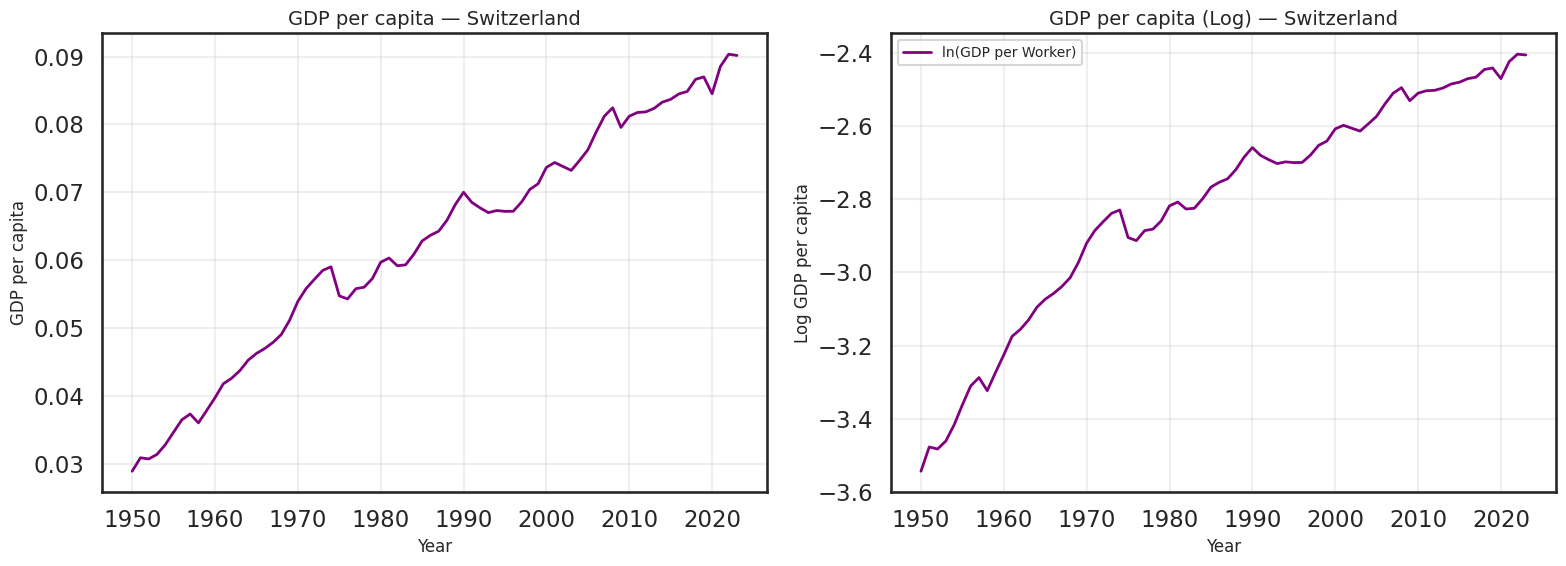

In [ ]:
# Plotting labour productivity (GDP per capita) of Switzerland over time

# Calculating GDP per capita and its log
GDP_per_cap = Y / N # defining GDP per capita by dividing GDP Y by population N
ln_GDP_per_cap = np.log(GDP_per_cap) # transforming GDP per capita into natural log of GDP per capita
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # plotting the subplots horizontally

# Plot 1: Levels
axes[0].plot(year, GDP_per_cap, linewidth=2, color='purple', label='GDP per Capita (Y/N)') # plotting GDP per capita
axes[0].set_xlabel('Year', fontsize=12) # labelling x axis as "year"
axes[0].set_ylabel('GDP per capita', fontsize=12) # labelling y axis as "GDP per capita"
axes[0].set_title('GDP per capita — Switzerland', fontsize=14) # setting the title
axes[0].grid(True, alpha=0.3) # adding a light grid for readability

# Plot 2: Log levels
axes[1].plot(year, ln_GDP_per_cap, linewidth=2, color='purple', label='ln(GDP per Worker)') # plotting natural log of GDP per capita

axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Log GDP per capita', fontsize=12)
axes[1].set_title('GDP per capita (Log) — Switzerland', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout() # adjusting spacing
plt.show()

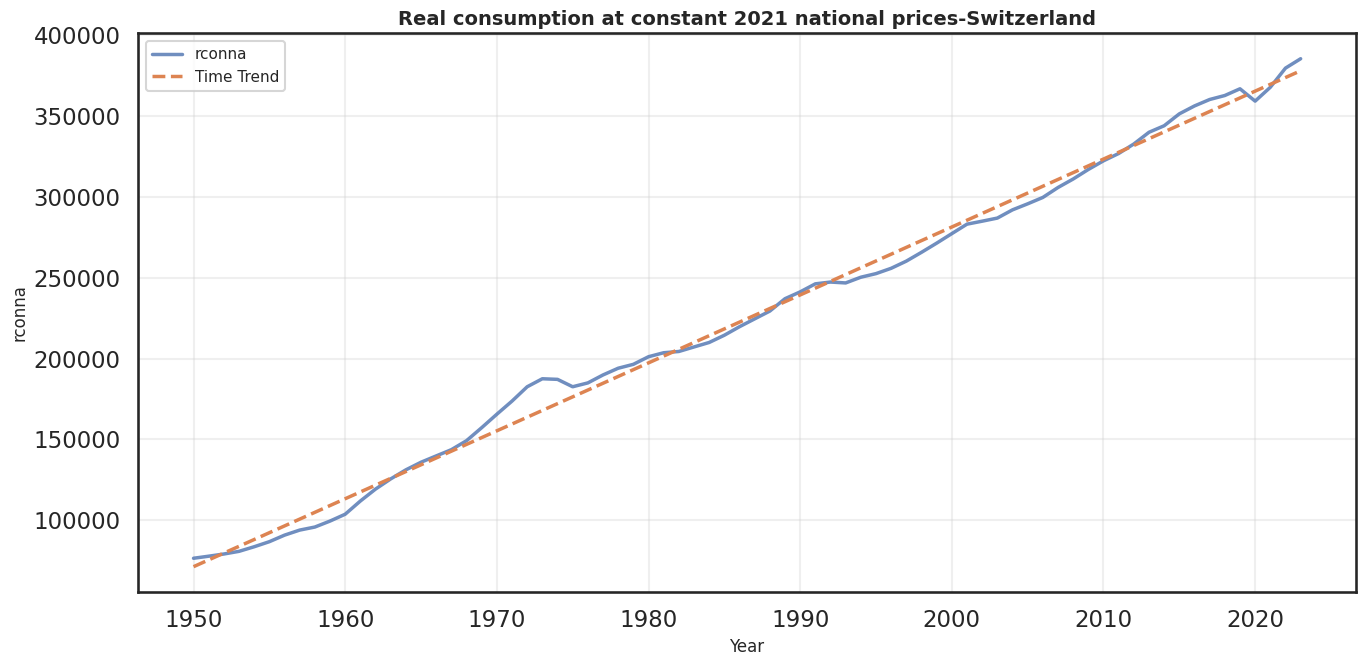

In [ ]:
# Plotting the time trends for real consumption at constant 2021 national prices
# Extracting the data for real consumption and storing it in rconna
rconna = data["rconna"].values

# Creating the time variable for trend
t = np.arange(len(year)) # creates a numeric index array with one value per year (number of years in our sample)

# Fitting linear trend: rconna = a + b*t
coef = np.polyfit(t, rconna, 1) # Fits a straight line (degree 1 polynomial) to the data. Finds the best-fit values of a and b using least squares and returns the coefficients a and b.
trend_rconna = coef[0] * t + coef[1] # obtaining the fitted trend line by substituting coefficients a (intercept) and b (slope) into the linear regression

# Plotting rconna and its time trend
fig3, ax3 = plt.subplots(figsize=(14, 7)) # graph of size 14 x 7

ax3.plot(year, rconna, linewidth=2.5, label="rconna", alpha=0.8) # plotting real consumption (actual data)
ax3.plot(year, trend_rconna, linestyle="--", linewidth=2.5, label="Time Trend") # plotting the fitted trend line

ax3.set_xlabel("Year", fontsize=12) # labelling x axis as "year"
ax3.set_ylabel("rconna", fontsize=12) # labelling y axis as "rconna"
ax3.set_title("Real consumption at constant 2021 national prices-Switzerland", fontsize=14, fontweight="bold") # setting the title

ax3.legend(fontsize=11) # to display the legend
ax3.grid(True, alpha=0.3) # adding a light grid for readability

plt.tight_layout() # adjusting spacing
plt.show()


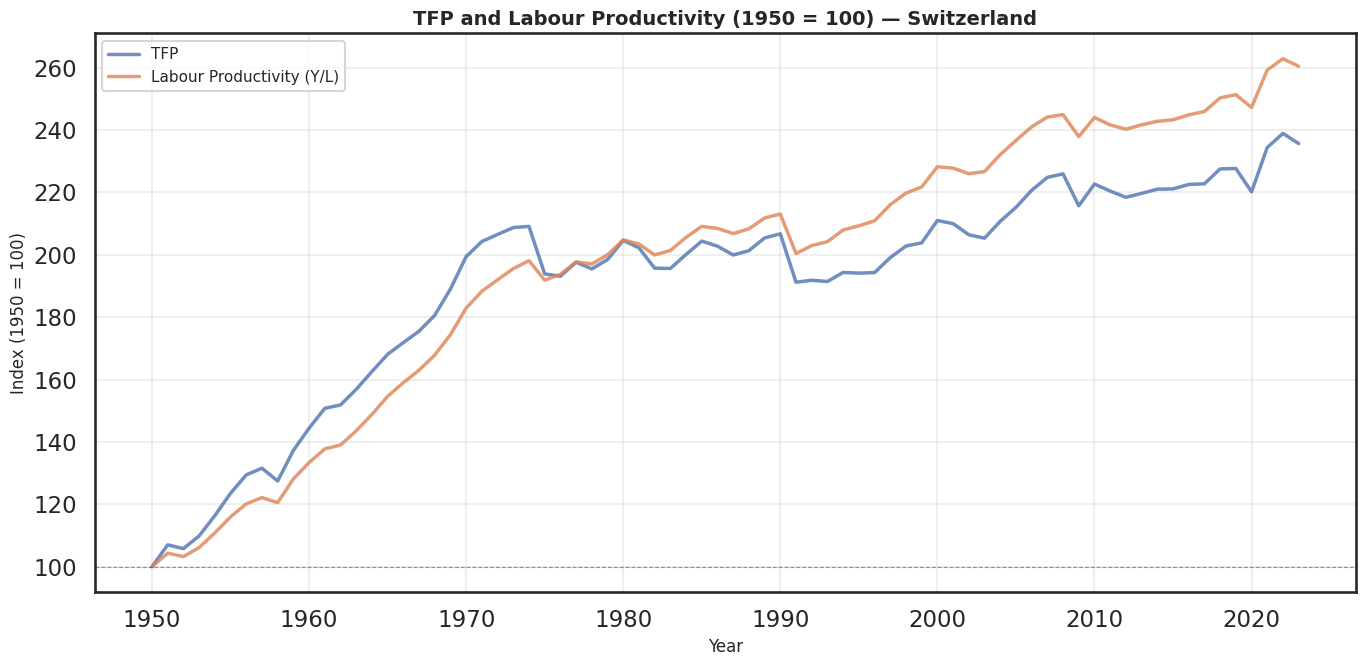

In [ ]:
# Plotting TFP and Labour Productivity in the same graph, indexed to the intial year 1950
# TFP - calculated from human capital adjusted (Labour) production function
# Index both series to 1950 = 100 # Indexing is done to ensure accurate comparision of variables

TFP_indexed = 100 * TFP_2 / TFP_2[0] # indexed TFP
LP = Y / L # defining labour productivity as GDP per worker
LP_indexed = 100 * LP / LP[0] # indexed labour productivity

fig, ax = plt.subplots(figsize=(14, 7)) # plotting subplots of size 14 x 7

ax.plot(year, TFP_indexed, linewidth=2.5, label="TFP", alpha=0.8) # plot with indexed TFP in the y axis and year in the x axis
ax.plot(year, LP_indexed, linewidth=2.5, label="Labour Productivity (Y/L)", alpha=0.8) # plot with indexed labour productivity in the y axis and year in the x axis

ax.set_xlabel("Year", fontsize=12) # labelling x axis as "year"
ax.set_ylabel("Index (1950 = 100)", fontsize=12) # labelling y axis as "index"
ax.set_title("TFP and Labour Productivity (1950 = 100) — Switzerland", fontsize=14, fontweight="bold") # setting the title
ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.4) # adding a horizontal reference line at the index level 100 to highlight the base level for comparision
ax.legend(fontsize=11) # to display the legend
ax.grid(True, alpha=0.3) # adding a light grid for readability

plt.tight_layout() # adjusting spacing
plt.show()

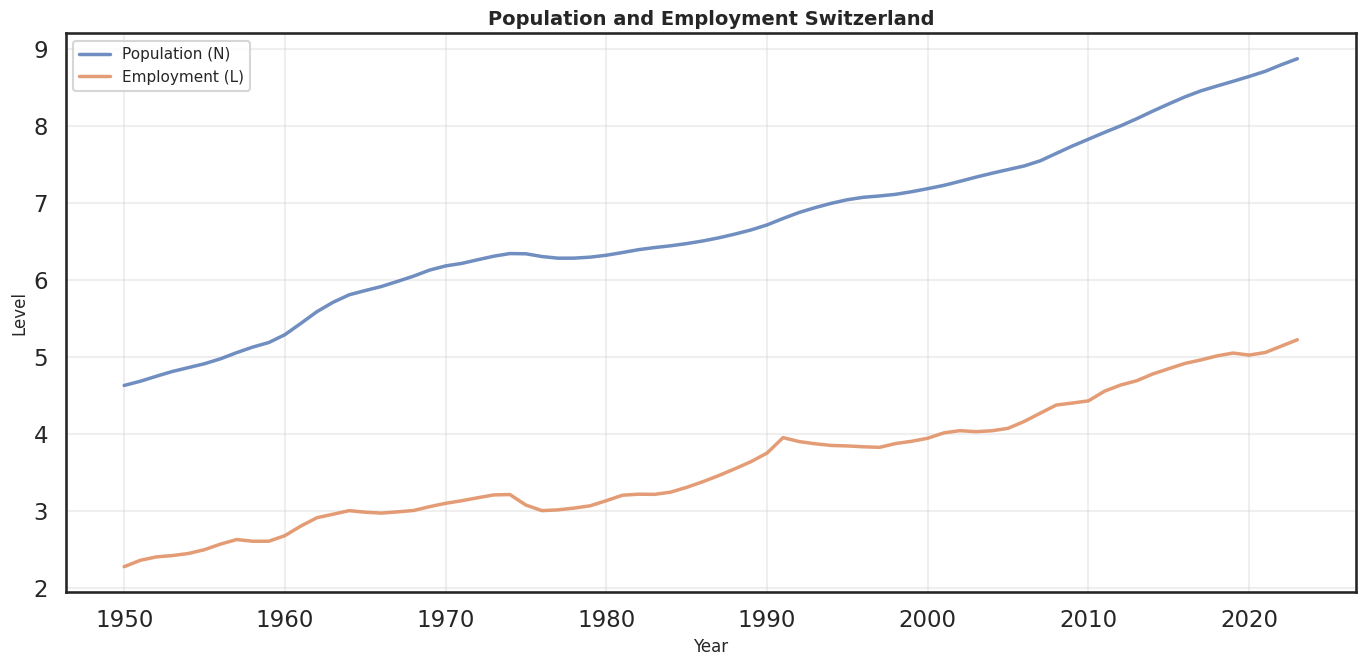

In [ ]:
# Plotting population and employment over time in the same graph

L = data["emp"]  # Assigning the data on employment to L
N = data["pop"]  # Assigning the data on population to N

year = data["year"].values  # takes values (year) from the 'year' column. Converts it into a NumPy array and stores it in year

fig, ax = plt.subplots(figsize=(14, 7)) # plotting a graph of size 14 x 7

ax.plot(year, N, linewidth=2.5, label="Population (N)", alpha=0.8) # plot with population in y axis and years in x axis
ax.plot(year, L, linewidth=2.5, label="Employment (L)", alpha=0.8) # plot with employment in y axis and years in x axis

ax.set_xlabel("Year", fontsize=12) # labelling x axis as "year"
ax.set_ylabel("Level", fontsize=12) # labelling y axis "level"
ax.set_title("Population and Employment Switzerland",
             fontsize=14, fontweight="bold") # setting the title

ax.legend(fontsize=11) # to display the legend
ax.grid(True, alpha=0.3) # adding a light grid for readability

plt.tight_layout() # adjusting spacing
plt.show()


Average Annual Log Growth Rates Across Sub-Periods
   Period  Years  Avg_Annual_Log_GDP_Growth_%  Avg_Annual_Log_GDP_PC_Growth_%
1950-1974     24                     4.284437                        2.848903
1975-1992     17                     1.727236                        0.330385
1993-2006     13                     1.830243                        1.275050
2007-2023     16                     1.663666                        0.403681


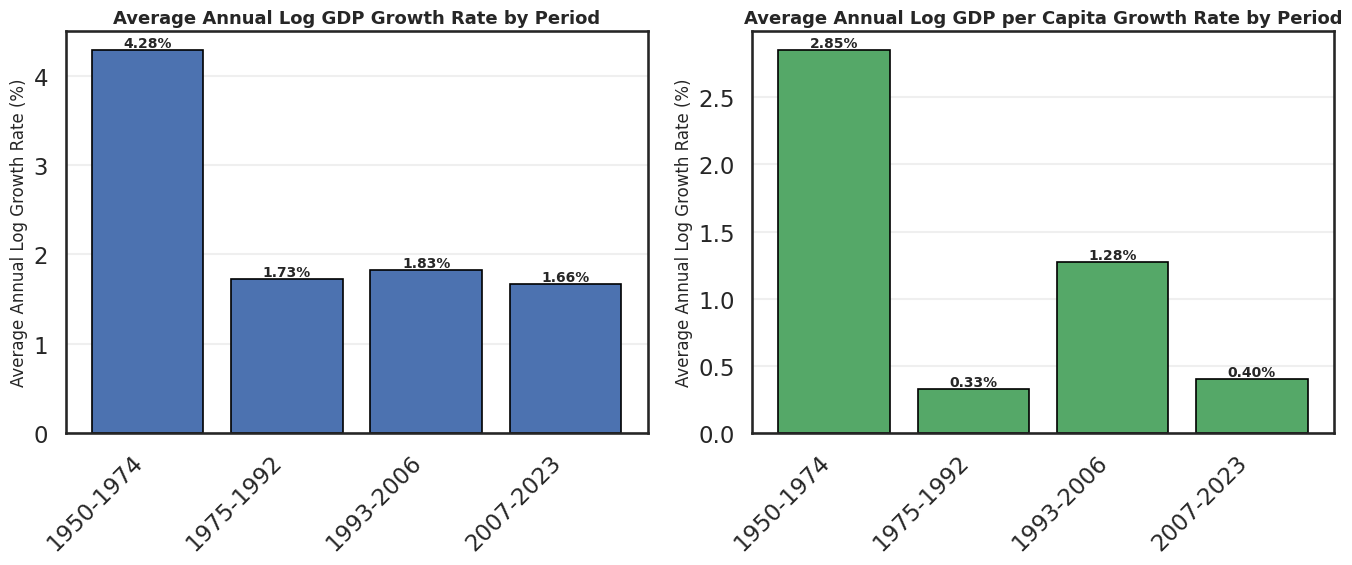


Summary Statistics:
Average Annual Log GDP Growth (across all periods):           2.38%
Average Annual Log GDP per Capita Growth (across all periods): 1.21%
Highest Avg Annual Log GDP Growth Period:              1950-1974
Highest Avg Annual Log GDP per Capita Growth Period:   1950-1974


In [ ]:
growth_rates = [] #Creating an empty list to store growth rates

periods = [ #Creating a list of tuples that includes all the four sub periods
    (1950, 1974),
    (1975, 1992),
    (1993, 2006),
    (2007, 2023),
]

for period_start, period_end in periods:

    start_idx = np.where(year == period_start)[0]
    end_idx = np.where(year == period_end)[0]

    # Skip if either year is missing
    if len(start_idx) == 0 or len(end_idx) == 0:
        continue

    start_idx = start_idx[0]
    end_idx = end_idx[0]

    # Calculating number of years in period
    n_years = period_end - period_start

    # Log growth rate for GDP: g_Y = ln(Y_end / Y_start) = ln(Y_end) - ln(Y_start)
    log_gdp_growth = (np.log(Y[end_idx]) - np.log(Y[start_idx])) / n_years  # divide by n_years here

    # Obtaining Log growth rate for GDP per capita
    y_start = Y[start_idx] / L[start_idx]
    y_end = Y[end_idx] / L[end_idx]
    log_gdp_pc_growth = (np.log(y_end) - np.log(y_start)) / n_years  # divide by n_years here

    growth_rates.append({
        "Period": f"{period_start}-{period_end}",
        "Years": n_years,
        "Avg_Annual_Log_GDP_Growth": log_gdp_growth,
        "Avg_Annual_Log_GDP_Growth_%": log_gdp_growth * 100,
        "Avg_Annual_Log_GDP_PC_Growth": log_gdp_pc_growth,
        "Avg_Annual_Log_GDP_PC_Growth_%": log_gdp_pc_growth * 100
    })

# Converting growth_rates to DataFrame for easy viewing
growth_df = pd.DataFrame(growth_rates)

# Displaying results
print("\nAverage Annual Log Growth Rates Across Sub-Periods")
print("=" * 80)
print(growth_df[["Period", "Years", "Avg_Annual_Log_GDP_Growth_%", "Avg_Annual_Log_GDP_PC_Growth_%"]].to_string(index=False))

# Visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

periods_labels = growth_df["Period"] # labelli
log_gdp_growth = growth_df["Avg_Annual_Log_GDP_Growth_%"]
log_gdp_pc_growth = growth_df["Avg_Annual_Log_GDP_PC_Growth_%"]

# Plot 1: Average Annual Log GDP Growth
bars1 = ax1.bar(periods_labels, log_gdp_growth, color='#4C72B0', edgecolor='black', linewidth=1.2)
ax1.set_ylabel('Average Annual Log Growth Rate (%)', fontsize=12)
ax1.set_title('Average Annual Log GDP Growth Rate by Period', fontsize=13, fontweight='bold')
ax1.set_xticks(np.arange(len(periods_labels))) # Set tick locations explicitly
ax1.set_xticklabels(periods_labels, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.8)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Average Annual Log GDP per Capita Growth
bars2 = ax2.bar(periods_labels, log_gdp_pc_growth, color='#55A868', edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Average Annual Log Growth Rate (%)', fontsize=12) # labelling y axis
ax2.set_title('Average Annual Log GDP per Capita Growth Rate by Period', fontsize=13, fontweight='bold') # setting the title
ax2.set_xticks(np.arange(len(periods_labels))) # Setting tick locations explicitly
ax2.set_xticklabels(periods_labels, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3) # adding a light grid for readability
ax2.axhline(0, color='black', linewidth=0.8)

# Adding value labels
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 80)
print("Summary Statistics:")
print(f"Average Annual Log GDP Growth (across all periods):           {growth_df['Avg_Annual_Log_GDP_Growth_%'].mean():.2f}%")
print(f"Average Annual Log GDP per Capita Growth (across all periods): {growth_df['Avg_Annual_Log_GDP_PC_Growth_%'].mean():.2f}%")
print(f"Highest Avg Annual Log GDP Growth Period:              {growth_df.loc[growth_df['Avg_Annual_Log_GDP_Growth_%'].idxmax(), 'Period']}")
print(f"Highest Avg Annual Log GDP per Capita Growth Period:   {growth_df.loc[growth_df['Avg_Annual_Log_GDP_PC_Growth_%'].idxmax(), 'Period']}")

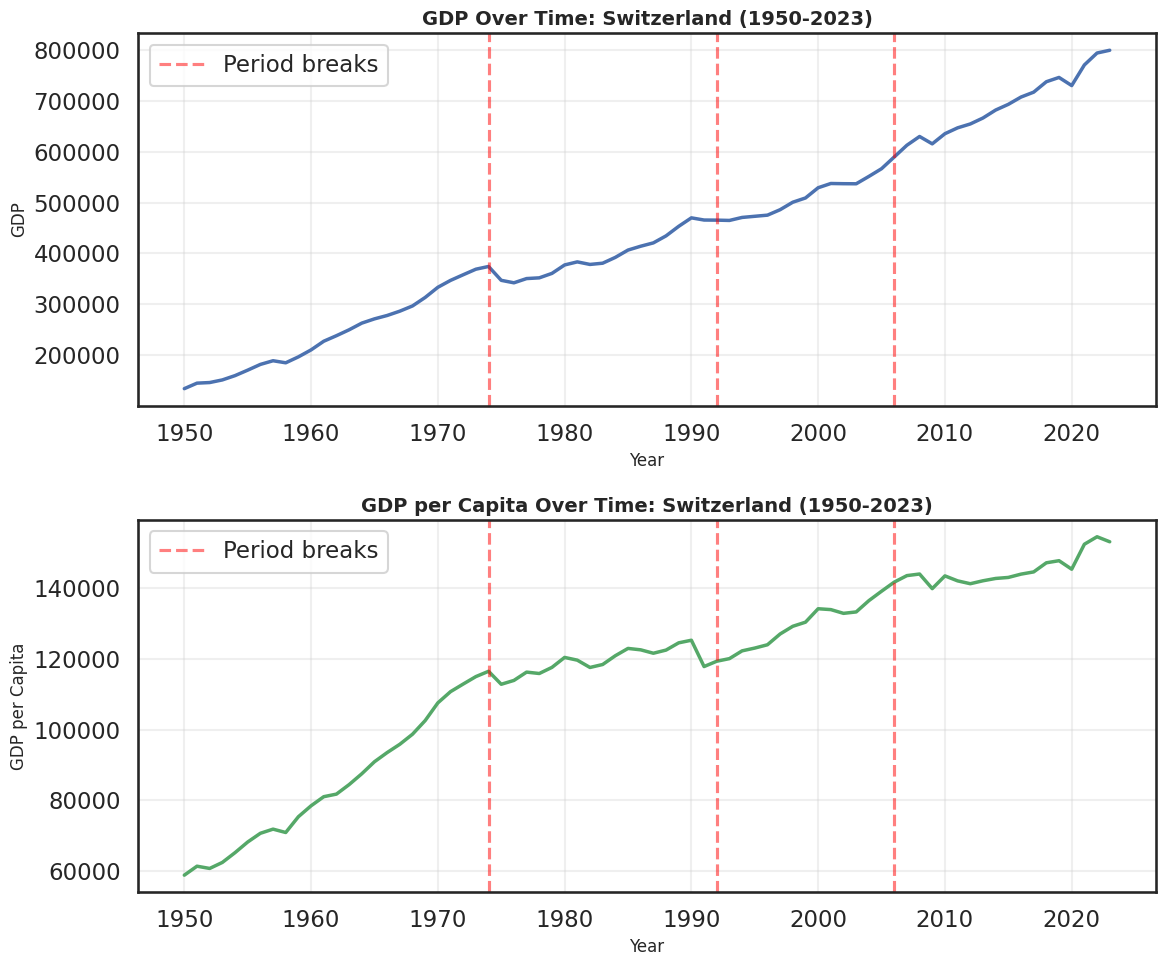

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

year = data["year"].values #Takes the year column from the data and converts it into a NumPy array that Python can use

gdp_per_capita = Y / L #Calculating GDP per capita

df_plot = pd.DataFrame({ #Generating a data frame
    'Year': year, #Assigns the first column of the data frame to be the variable year
    'GDP': Y, #Assigns the first column of the data frame to be the variable year
    'GDP_per_Capita': gdp_per_capita #Assigns the second column of the data frame to be the variable GDP per capita
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10)) #Creating two subplots stacked vertically

ax1.plot(df_plot['Year'], df_plot['GDP'], color='#4C72B0', linewidth=2.5) #Plotting a line graph with years on the x-axis and GDP on the y-axis
ax1.set_xlabel('Year', fontsize=12) #Adding x axis label
ax1.set_ylabel('GDP', fontsize=12) #Adding y axis label
ax1.set_title('GDP Over Time: Switzerland (1950-2023)', fontsize=14, fontweight='bold') #Adding title to the graph
ax1.grid(True, alpha=0.3) #Adding a grid
ax1.axvline(x=1974, color='red', linestyle='--', alpha=0.5, label='Period breaks') #Adding vertical lines for period breaks
ax1.axvline(x=1992, color='red', linestyle='--', alpha=0.5)
ax1.axvline(x=2006, color='red', linestyle='--', alpha=0.5)
ax1.legend() #Adding legend box

ax2.plot(df_plot['Year'], df_plot['GDP_per_Capita'], color='#55A868', linewidth=2.5) #Doing the same for GDP per capita
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('GDP per Capita', fontsize=12)
ax2.set_title('GDP per Capita Over Time: Switzerland (1950-2023)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axvline(x=1974, color='red', linestyle='--', alpha=0.5, label='Period breaks') #Adding vertical lines for period breaks
ax2.axvline(x=1992, color='red', linestyle='--', alpha=0.5)
ax2.axvline(x=2006, color='red', linestyle='--', alpha=0.5)
ax2.legend() # Adding legend box

plt.tight_layout() #Adjusting spacing
plt.show() #Printing the plots

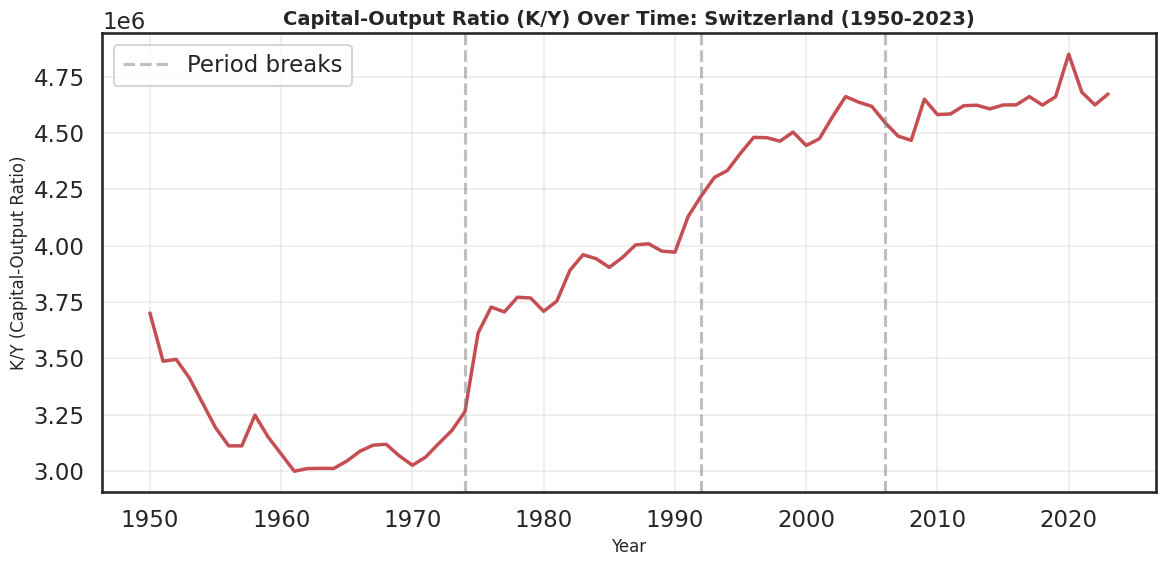

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

year = data["year"].values #Takes the year column from the data and converts it into a NumPy array that Python can use

capital_output_ratio = K / Y #Calculating capital output ratio

df_plot = pd.DataFrame({ #Generating a data frame
    'Year': year, #Assigns the first column of the data frame to be the variable year
    'K_over_Y': capital_output_ratio #Assigns the second column of the data frame to be the variable Capital Output Ratio
})

fig, ax = plt.subplots(figsize=(12, 6)) # Generating a black area (12x6) to plot a graph

ax.plot(df_plot['Year'], df_plot['K_over_Y'], color='#C44E52', linewidth=2.5) #Year is assigned to be on the X axis and Capital-Output ratio on the Y axis
ax.set_xlabel('Year', fontsize=12) #Labelling the X axis as 'Year'
ax.set_ylabel('K/Y (Capital-Output Ratio)', fontsize=12) #Labelling the Y axis as 'Capital-Output Ratio'
ax.set_title('Capital-Output Ratio (K/Y) Over Time: Switzerland (1950-2023)', #Adding a title to the graph
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3) # Adding grids to the graph

ax.axvline(x=1974, color='gray', linestyle='--', alpha=0.5, label='Period breaks')
ax.axvline(x=1992, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=2006, color='gray', linestyle='--', alpha=0.5) #Adding vertical dashed lines for the years 1974, 1992 and 2006 on the graph for the different sub-periods

ax.legend() # Adding a legend to the graph for 'Period breaks'
plt.tight_layout() # Adjusting the layout to prevent overlapping
plt.show() #Displaying the plot


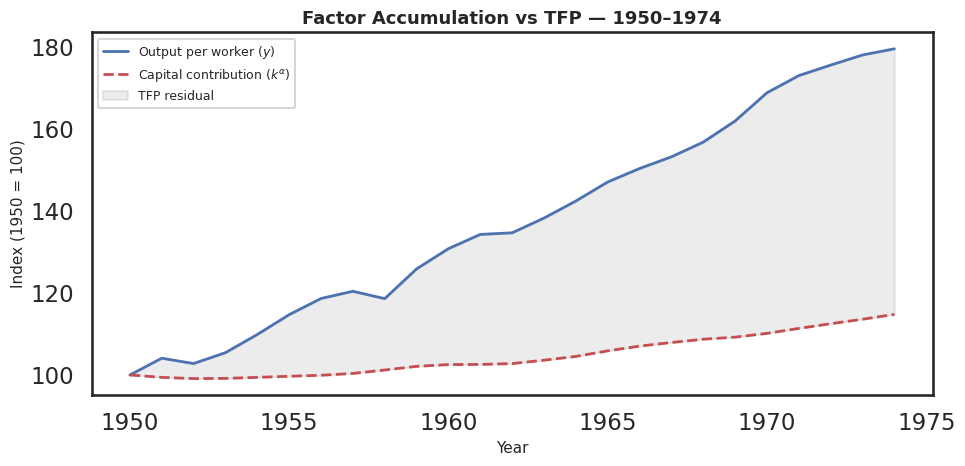

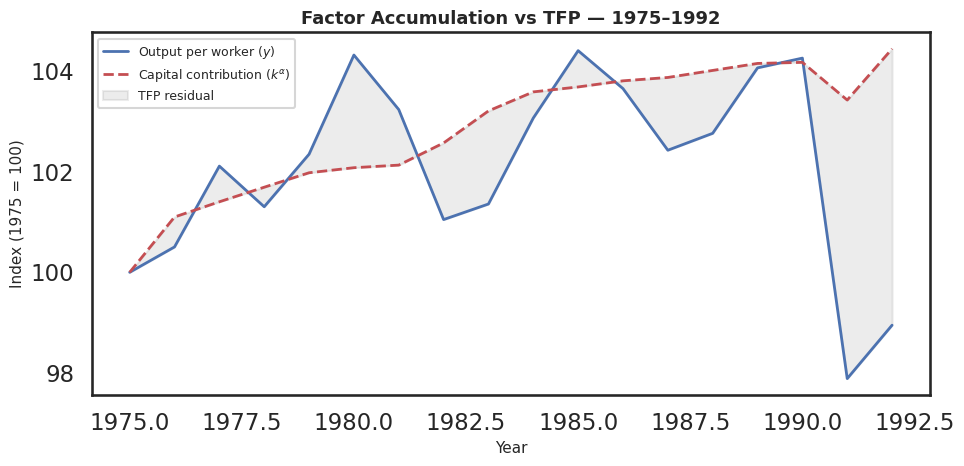

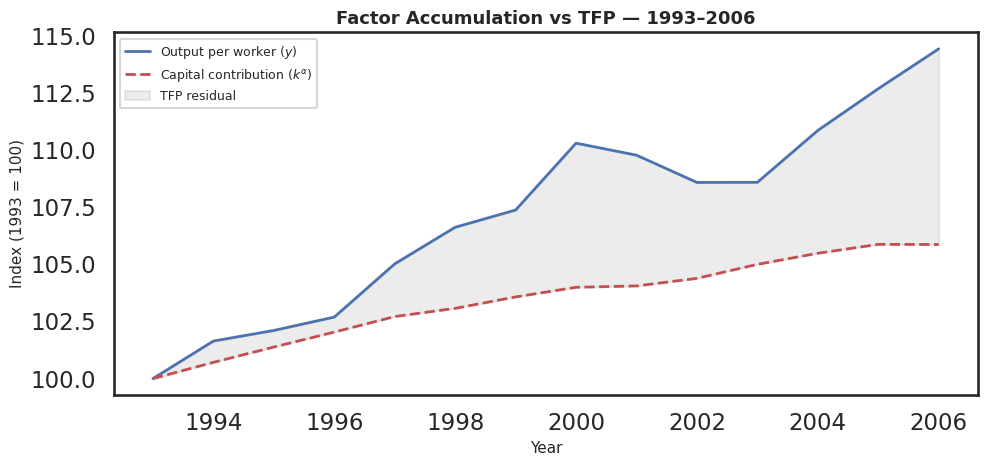

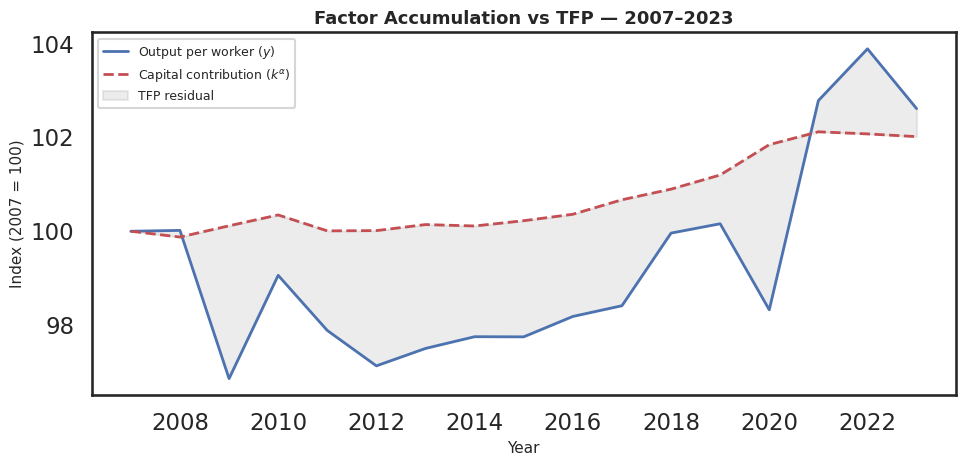

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Our graphs that support our Solow Analysis:

# Basic parameters
COUNTRY_CODE = 'CHE'   # CHE = Switzerland in the Penn World Tables country codes
ALPHA = 0.3

# Load the Penn World Tables dataset from Google Drive
data_path = "/content/drive/MyDrive/Macro_Project_jan26/pwt.xlsx"
df_all = pd.read_excel(data_path, sheet_name='Data', engine='openpyxl')

# Keep only Switzerland
df_che = df_all[df_all['countrycode'] == COUNTRY_CODE].copy()

# --- Build the key variables ---
# Effective labour = employment × human capital index
# We want labour in "efficiency units"
df_che['L_effective'] = df_che['emp'] * df_che['hc']

# Output per effective worker ("y" in the Solow model)
df_che['y'] = df_che['rgdpna'] / df_che['L_effective']

# Capital per effective worker ("k" in the Solow model)
# rnna is the capital stock at constant national prices
df_che['k'] = df_che['rnna'] / df_che['L_effective']

# ==============================================================================
# PERIOD 1: 1950–1974, post war period
# ==============================================================================
df1 = df_che[(df_che['year'] >= 1950) & (df_che['year'] <= 1974)].copy()

# We index both series to 100 at the start of the period so they're comparable.
# The idea: if y and k^alpha move together, capital accumulation explains growth.
# If y grows way faster than k^alpha, then TFP (technology) is doing more
y_idx1 = 100 * df1['y']          / df1['y'].iloc[0]
k_idx1 = 100 * df1['k'] ** ALPHA / df1['k'].iloc[0] ** ALPHA
# k^alpha is not the full capital stock, it's capital's contribution to output

fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df1['year'], y_idx1, 'b-',  linewidth=2, label='Output per worker ($y$)')
ax1.plot(df1['year'], k_idx1, 'r--', linewidth=2, label='Capital contribution ($k^{\\alpha}$)')
# The shaded area between the two lines is the TFP residual
# so a large gray area = TFP matters a lot
ax1.fill_between(df1['year'], y_idx1, k_idx1, color='gray', alpha=0.15, label='TFP residual')
ax1.set_title('Factor Accumulation vs TFP — 1950–1974', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Index (1950 = 100)', fontsize=11)
ax1.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ==============================================================================
# PERIOD 2: 1975–1992
# Oil shocks era + stagflation
# ==============================================================================
df2 = df_che[(df_che['year'] >= 1975) & (df_che['year'] <= 1992)].copy()

y_idx2 = 100 * df2['y']          / df2['y'].iloc[0]
k_idx2 = 100 * df2['k'] ** ALPHA / df2['k'].iloc[0] ** ALPHA

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(df2['year'], y_idx2, 'b-',  linewidth=2, label='Output per worker ($y$)')
ax2.plot(df2['year'], k_idx2, 'r--', linewidth=2, label='Capital contribution ($k^{\\alpha}$)')
ax2.fill_between(df2['year'], y_idx2, k_idx2, color='gray', alpha=0.15, label='TFP residual')
ax2.set_title('Factor Accumulation vs TFP — 1975–1992', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Index (1975 = 100)', fontsize=11)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ==============================================================================
# PERIOD 3: 1993–2006
# More stable period globally
# ==============================================================================
df3 = df_che[(df_che['year'] >= 1993) & (df_che['year'] <= 2006)].copy()

y_idx3 = 100 * df3['y']          / df3['y'].iloc[0]
k_idx3 = 100 * df3['k'] ** ALPHA / df3['k'].iloc[0] ** ALPHA

fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.plot(df3['year'], y_idx3, 'b-',  linewidth=2, label='Output per worker ($y$)')
ax3.plot(df3['year'], k_idx3, 'r--', linewidth=2, label='Capital contribution ($k^{\\alpha}$)')
ax3.fill_between(df3['year'], y_idx3, k_idx3, color='gray', alpha=0.15, label='TFP residual')
ax3.set_title('Factor Accumulation vs TFP — 1993–2006', fontsize=13, fontweight='bold')
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Index (1993 = 100)', fontsize=11)
ax3.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ==============================================================================
# PERIOD 4: 2007–2023
# Global financial crisis + COVID + technology improvements
# ==============================================================================
df4 = df_che[(df_che['year'] >= 2007) & (df_che['year'] <= 2023)].copy()

y_idx4 = 100 * df4['y']          / df4['y'].iloc[0]
k_idx4 = 100 * df4['k'] ** ALPHA / df4['k'].iloc[0] ** ALPHA

fig4, ax4 = plt.subplots(figsize=(10, 5))
ax4.plot(df4['year'], y_idx4, 'b-',  linewidth=2, label='Output per worker ($y$)')
ax4.plot(df4['year'], k_idx4, 'r--', linewidth=2, label='Capital contribution ($k^{\\alpha}$)')
ax4.fill_between(df4['year'], y_idx4, k_idx4, color='gray', alpha=0.15, label='TFP residual')
ax4.set_title('Factor Accumulation vs TFP — 2007–2023', fontsize=13, fontweight='bold')
ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Index (2007 = 100)', fontsize=11)
ax4.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set your folder and file name
folder_path = '/content/drive/MyDrive/Macroeconomics_II_Jan2026'
file_name = 'Inflation_Unemployment.csv'
full_path = os.path.join(folder_path, file_name)

if os.path.exists(full_path):
    df = pd.read_csv(full_path)

    # Access "Inflation" by filtering the Series Name column
    data = df[(df['Country Name'] == 'Switzerland') &
              (df['Series Name'].str.contains('Inflation', na=False))]

    if not data.empty:
        years = data.iloc[:, 4:].columns.str.extract(r'(\d+)')[0]
        values = pd.to_numeric(data.iloc[:, 4:].values.flatten(), errors='coerce')

        plt.figure(figsize=(10, 5))
        plt.plot(years, values, color='#1f77b4', linewidth=2)

        plt.title('Switzerland: Inflation Rate (Annual %)', fontsize=14)
        plt.ylabel('Percentage (%)')
        plt.xticks(years[::5], rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print("Could not find Inflation data in the CSV.")